# Final plots bachelor project (part 1)
Created 2025-05-10

Summary of all the plots created for the bachelor thesis

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import itertools
from typing import Literal

import matplotlib as mpl
from matplotlib.axes._axes import Axes
from matplotlib.figure import Figure
import matplotlib.patches

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import scipy

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'


In [2]:
# Settings

# Path to resource folder with the structures and metadata tables
path_resources = Path(r"D:\Eigene Datein\dev\Uni\JGU Bio Bachelorthesis\Daten\resources")

path_AF2 = path_resources / "AF2"
path_AF3 = path_resources / "AF3_hydrogens"
path_solved = path_resources / "solved"

In [3]:
dataAF2 = pd.read_csv(path_AF2 / "AF2_metrics.tsv", sep="\t")
for c in ["chainA_start", "chainA_end", "chainB_start", "chainB_end", "num_mutations", "num_align_atoms_domain", "num_align_resi_domain", "hbonds", "salt_bridges", "hydrophobic_interactions"]:
    if c not in dataAF2.columns:
        print(f"Column {bcolors.FAIL}{c}{bcolors.ENDC} not (yet) in data frame")
        continue
    dataAF2[c] = dataAF2[c].astype(pd.Int64Dtype())
dataAF2["score_rank"] = dataAF2.groupby("prediction_name")["model_confidence"].rank("first", ascending=False).astype(pd.Int64Dtype())
dataAF2["RMSD_rank"] = dataAF2.groupby("prediction_name")["RMSD_all_atom"].rank("first").astype(pd.Int64Dtype())
dataAF2["RMSD_peptide_rank"] = dataAF2.groupby("prediction_name")["RMSD_all_atom_peptide"].rank("first").astype(pd.Int64Dtype())
dataAF2["DockQ_rank"] = dataAF2.groupby("prediction_name")["DockQ"].rank("first").astype(pd.Int64Dtype())
display(dataAF2)

,project_name,run_id,benchmark_set,prediction_name,model_id,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,buried_area,min_distance,disulfide_bonds,salt_bridges,hbonds,hydrophobic_interactions,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank
0,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,312,5,A,B,165,...,613.651,6.063,0.0,0,9,0,1,2,2,3
1,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,312,5,A,B,165,...,580.310,6.083,0.0,0,9,0,2,3,1,4
2,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,312,5,A,B,165,...,662.104,6.072,0.0,0,10,3,3,1,3,5
3,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,312,5,A,B,165,...,398.498,5.417,0.0,0,2,0,4,4,4,2
4,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,312,5,A,B,165,...,323.304,5.092,0.0,0,2,9,5,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,60,113,B,B,392,...,1617.382,5.591,0.0,3,7,56,1,1,<NA>,<NA>
3176,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,60,113,B,B,392,...,791.256,6.373,0.0,0,3,7,2,5,<NA>,<NA>
3177,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,60,113,B,B,392,...,882.547,7.906,0.0,1,2,11,3,4,<NA>,<NA>
3178,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,60,113,B,B,392,...,1020.896,4.628,0.0,3,7,44,4,3,<NA>,<NA>


In [4]:
dataAF3 = pd.read_csv(path_AF3 / f"{path_AF3.name}_metrics.tsv", sep="\t")
for c in ["chainA_start", "chainA_end", "chainB_start", "chainB_end", "num_mutations", "num_align_atoms_domain", "num_align_resi_domain", "hbonds", "salt_bridges", "hydrophobic_interactions"]:
    if c not in dataAF3.columns:
        print(f"Column {bcolors.FAIL}{c}{bcolors.ENDC} not (yet) in data frame")
        continue
    dataAF3[c] = dataAF3[c].astype(pd.Int64Dtype())
dataAF3["score_rank"] = dataAF3.groupby("prediction_name")["ranking_score"].rank("first", ascending=False).astype(pd.Int64Dtype())
dataAF3["RMSD_rank"] = dataAF3.groupby("prediction_name")["RMSD_all_atom"].rank("first").astype(pd.Int64Dtype())
dataAF3["RMSD_peptide_rank"] = dataAF3.groupby("prediction_name")["RMSD_all_atom_peptide"].rank("first").astype(pd.Int64Dtype())
dataAF3["DockQ_rank"] = dataAF3.groupby("prediction_name")["DockQ"].rank("first").astype(pd.Int64Dtype())
display(dataAF3)

,model_preset,benchmark_set,prediction_name,model_id,ranking_score,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,min_distance,disulfide_bonds,salt_bridges,hbonds,hydrophobic_interactions,ipSAE,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,6.241,0,0,10,0,0.869025,1,2,1,5
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,6.207,0,0,11,0,0.868551,2,3,3,3
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,5.810,0,0,13,0,0.855837,3,5,4,1
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,6.264,0,0,11,0,0.850758,4,1,2,4
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,5.890,0,0,14,0,0.850449,5,4,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,5.367,0,2,1,0,0.012324,1,1,<NA>,<NA>
3176,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,6.907,0,2,2,15,0.000000,2,5,<NA>,<NA>
3177,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,6.442,0,2,4,0,0.000000,3,4,<NA>,<NA>
3178,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,4.914,0,1,2,48,0.000000,4,3,<NA>,<NA>


In [5]:
dataSolved = pd.read_csv(path_solved / "solved_hydrogens_metrics.tsv", sep="\t")
display(dataSolved)

,set,PDB_id,DDI_pfam_id,path,chainA_id,chainB_id,min_distance,buried_area,salt_bridges,hbonds,disulfide_bonds,hydrophobic_interactions
0,DMI,1ATP,NaN,DMI_hydrogens\1ATP_min_DMI.pdb,A,B,6.273,808.592,0,1,0,77
1,DMI,1AXC,NaN,DMI_hydrogens\1AXC_min_DMI.pdb,A,B,4.174,1209.332,0,4,0,62
2,DMI,1B72,NaN,DMI_hydrogens\1B72_min_DMI.pdb,A,B,5.182,547.149,0,1,0,36
3,DMI,1B8Q,NaN,DMI_hydrogens\1B8Q_min_DMI.pdb,A,B,4.376,871.756,0,4,0,42
4,DMI,1BXX,NaN,DMI_hydrogens\1BXX_min_DMI.pdb,A,B,4.435,783.465,0,6,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...
183,DDI,3ZNI,PF14447_PF00179,DDI_hydrogens\PF14447_PF00179_3ZNI_AC.pdb,A,C,5.268,1288.881,0,10,0,85
184,DDI,3J7Y,PF14978_PF00327,DDI_hydrogens\PF14978_PF00327_3J7Y_oZ.pdb,o,Z,4.885,2488.556,0,8,0,70
185,DDI,6D6Q,PF15985_PF10175,DDI_hydrogens\PF15985_PF10175_6D6Q_GL.pdb,G,L,3.891,3659.160,1,12,0,167
186,DDI,3KZ1,PF17838_PF00071,DDI_hydrogens\PF17838_PF00071_3KZ1_BE.pdb,B,E,5.276,1249.398,2,10,0,60


In [6]:
dataAF = pd.merge(
    left=dataAF3,
    right=dataAF2,
    left_on=["benchmark_set", "prediction_name", "model_id"],
    right_on=["benchmark_set", "prediction_name", "model_id"],
    suffixes=["_AF3", "_AF2"],
    how="inner"
)
for c in ["chainA_length", "chainB_length", "chainA_id", "chainB_id", "chainA_start", "chainA_end", "chainB_start", "chainB_end", "PDB_id", "ELM_instance", "DDI_pfam_id", "PDB_id_random_paired", "ELM_instance_random_paired", "DDI_pfam_id_random_paired", "sequence_initial", "sequence_mutated", "num_mutations", "score_rank"]:
    if len(dataAF[~(dataAF[c+"_AF2"] == dataAF[c+"_AF3"]) & (~dataAF[c+"_AF2"].isna()) & (~dataAF[c+"_AF3"].isna())]) > 0:
        print(f"Unmatched column {c}")
        continue
    dataAF.drop(columns=[c+"_AF2"], inplace=True)
    dataAF.rename(columns={c+"_AF3": c}, inplace=True)
dataAF.rename(columns={"ranking_score": "ranking_score_AF3"}, inplace=True)
dataAF.rename(columns={"model_confidence": "model_confidence_AF2"}, inplace=True)
dataAF.rename(columns={"ipSAE": "ipSAE_AF3"}, inplace=True)

display(dataAF)

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,Fnonnat_AF2,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0.086957,613.651,6.063,0.0,0,9,0,2,2,3
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0.050000,580.310,6.083,0.0,0,9,0,3,1,4
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0.185185,662.104,6.072,0.0,0,10,3,1,3,5
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0.363636,398.498,5.417,0.0,0,2,0,4,4,2
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0.888889,323.304,5.092,0.0,0,2,9,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,NaN,1617.382,5.591,0.0,3,7,56,1,<NA>,<NA>
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,NaN,791.256,6.373,0.0,0,3,7,5,<NA>,<NA>
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,NaN,882.547,7.906,0.0,1,2,11,4,<NA>,<NA>
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,NaN,1020.896,4.628,0.0,3,7,44,3,<NA>,<NA>


In [7]:
# Stop cell designed to crash to allow "Run All" command in Jupyter notebooks to stop here
raise Exception("STOP")

Exception: STOP

### 0 Count of data

In [ ]:
dataAF2[(dataAF2["benchmark_set"] == "known_DMI") & (dataAF2["model_id"] == "ranked_0")]

,project_name,run_id,benchmark_set,prediction_name,model_id,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,DockQ,iRMSD,LRMSD,Fnonnat,buried_area,min_distance,disulfide_bonds,salt_bridges,hbonds,hydrophobic_interactions
0,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,312,5,A,B,165,...,0.878344,0.603831,1.575394,0.086957,613.651,6.063,0.0,0,9,0
5,AlphaFold_benchmark,run37,known_DMI,DEG_COP1_1_5IGO,ranked_0,324,8,A,B,352,...,0.203083,3.647857,11.785731,0.818182,1025.173,5.075,0.0,0,6,54
10,AlphaFold_benchmark,run37,known_DMI,DEG_Kelch_Keap1_1_2FLU,ranked_0,285,6,A,B,325,...,0.956840,0.406243,0.409987,0.135135,853.680,5.658,0.0,4,12,6
15,AlphaFold_benchmark,run37,known_DMI,DEG_Kelch_Keap1_2_3WN7,ranked_0,286,7,A,B,324,...,0.627900,1.098010,3.811533,0.357143,847.029,5.699,0.0,2,4,18
20,AlphaFold_benchmark,run37,known_DMI,DEG_MDM2_SWIB_1_1YCR,ranked_0,80,8,A,B,30,...,0.927639,0.491499,0.974915,0.038462,969.729,4.725,0.0,0,2,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,AlphaFold_benchmark,run37,known_DMI,TRG_ER_FFAT_1_2RR3,ranked_0,125,9,A,B,4,...,0.832137,1.023273,1.642793,0.128205,1121.818,4.348,0.0,0,7,53
660,AlphaFold_benchmark,run37,known_DMI,TRG_LysEnd_GGAAcLL_1_1JWG,ranked_0,147,7,A,B,1,...,0.949574,0.470555,1.451951,0.093750,1066.671,5.933,0.0,1,6,60
665,AlphaFold_benchmark,run37,known_DMI,TRG_NES_CRM1_1_3GB8,ranked_0,179,16,A,B,447,...,0.683162,1.423170,2.824227,0.153846,1389.344,4.832,0.0,3,5,104
670,AlphaFold_benchmark,run37,known_DMI,TRG_NLS_Bipartite_1_1PJM,ranked_0,460,17,A,B,70,...,0.838144,0.780334,2.332849,0.160000,2256.518,4.881,0.0,4,20,50


In [ ]:
len(dataAF)

3170

In [ ]:
print(f'known DMI (AF2 only): {len(dataAF2[(dataAF2["benchmark_set"] == "known_DMI") & (dataAF2["model_id"] == "ranked_0")])}')
print(f'known DMI (AF3 only): {len(dataAF3[(dataAF3["benchmark_set"] == "known_DMI") & (dataAF3["model_id"] == "ranked_0")])}')
print(f'known DMI (dataAF): {len(dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")])}')

print(f'random DMI (AF2 only): {len(dataAF2[(dataAF2["benchmark_set"] == "random_DMI") & (dataAF2["model_id"] == "ranked_0")])}')
print(f'random DMI (AF3 only): {len(dataAF3[(dataAF3["benchmark_set"] == "random_DMI") & (dataAF3["model_id"] == "ranked_0")])}')
print(f'random DMI (dataAF): {len(dataAF[(dataAF["benchmark_set"] == "random_DMI") & (dataAF["model_id"] == "ranked_0")])}')

print(f'1 mutations DMI (AF2 only): {len(dataAF2[(dataAF2["benchmark_set"] == "mutations_DMI") & (dataAF2["model_id"] == "ranked_0") & (dataAF2["num_mutations"] == 1)])}')
print(f'1 mutations DMI (AF3 only): {len(dataAF3[(dataAF3["benchmark_set"] == "mutations_DMI") & (dataAF3["model_id"] == "ranked_0") & (dataAF3["num_mutations"] == 1)])}')
print(f'1 mutations DMI (dataAF): {len(dataAF[(dataAF["benchmark_set"] == "mutations_DMI") & (dataAF["model_id"] == "ranked_0") & (dataAF["num_mutations"] == 1)])}')

print(f'2 mutations DMI (AF2 only): {len(dataAF2[(dataAF2["benchmark_set"] == "mutations_DMI") & (dataAF2["model_id"] == "ranked_0") & (dataAF2["num_mutations"] == 2)])}')
print(f'2 mutations DMI (AF3 only): {len(dataAF3[(dataAF3["benchmark_set"] == "mutations_DMI") & (dataAF3["model_id"] == "ranked_0") & (dataAF3["num_mutations"] == 2)])}')
print(f'2 mutations DMI (dataAF): {len(dataAF[(dataAF["benchmark_set"] == "mutations_DMI") & (dataAF["model_id"] == "ranked_0") & (dataAF["num_mutations"] == 2)])}')

print(f'known DDI (AF2 only): {len(dataAF2[(dataAF2["benchmark_set"] == "known_DDI") & (dataAF2["model_id"] == "ranked_0")])}')
print(f'known DDI (AF3 only): {len(dataAF3[(dataAF3["benchmark_set"] == "known_DDI") & (dataAF3["model_id"] == "ranked_0")])}')
print(f'known DDI (dataAF): {len(dataAF[(dataAF["benchmark_set"] == "known_DDI") & (dataAF["model_id"] == "ranked_0")])}')

print(f'random DDI (AF2 only): {len(dataAF2[(dataAF2["benchmark_set"] == "random_DDI") & (dataAF2["model_id"] == "ranked_0")])}')
print(f'random DDI (AF3 only): {len(dataAF3[(dataAF3["benchmark_set"] == "random_DDI") & (dataAF3["model_id"] == "ranked_0")])}')
print(f'random DDI (dataAF): {len(dataAF[(dataAF["benchmark_set"] == "random_DDI") & (dataAF["model_id"] == "ranked_0")])}')

known DMI (AF2 only): 136
known DMI (AF3 only): 138
known DMI (dataAF): 136
random DMI (AF2 only): 136
random DMI (AF3 only): 136
random DMI (dataAF): 136
1 mutations DMI (AF2 only): 134
1 mutations DMI (AF3 only): 134
1 mutations DMI (dataAF): 134
2 mutations DMI (AF2 only): 134
2 mutations DMI (AF3 only): 134
2 mutations DMI (dataAF): 134
known DDI (AF2 only): 48
known DDI (AF3 only): 46
known DDI (dataAF): 46
random DDI (AF2 only): 48
random DDI (AF3 only): 48
random DDI (dataAF): 48


In [ ]:
dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0") & (dataAF["hbonds_AF2"].isna())]

In [ ]:
pdbs_knownDMI = set(dataAF[dataAF["benchmark_set"] == "known_DMI"]["PDB_id"])
pdbs_randomDMI1 = set(dataAF[dataAF["benchmark_set"] == "random_DMI"]["PDB_id"])
pdbs_randomDMI2 = set(dataAF[dataAF["benchmark_set"] == "random_DMI"]["PDB_id_random_paired"])
pdbs_mutations_DMI = set(dataAF[dataAF["benchmark_set"] == "mutations_DMI"]["PDB_id"])
pdbs_knownDDI = set(dataAF[dataAF["benchmark_set"] == "known_DDI"]["PDB_id"])
pdbs_randomDDI = set(dataAF[dataAF["benchmark_set"] == "random_DDI"]["PDB_id"])

display(pdbs_randomDMI1.union(pdbs_randomDMI2) - pdbs_knownDMI)
display(pdbs_knownDMI - pdbs_randomDMI1.union(pdbs_randomDMI2))
display(pdbs_knownDDI - pdbs_randomDDI)
display(pdbs_randomDDI - pdbs_knownDDI)

In [ ]:
dataAF[(dataAF["ranking_score_AF3"].isna()) & (dataAF["model_id"] == "ranked_0")]

In [ ]:
dataAF[(dataAF["PDB_id"] == "1G4B") & (dataAF["model_id"] == "ranked_0")]

In [ ]:
dataAF[dataAF["RMSD_all_atom_AF2"].isna() & (dataAF["model_id"] == "ranked_0")]

In [ ]:
# Checking if all structures are measured using the hydrophobic parameter
print(f'known DMI (AF2 only): {len(dataAF2[(dataAF2["benchmark_set"] == "known_DMI") & (dataAF2["model_id"] == "ranked_0") & ~(dataAF2["hydrophobic_interactions"].isna())])}')
print(f'known DMI (AF3 only): {len(dataAF3[(dataAF3["benchmark_set"] == "known_DMI") & (dataAF3["model_id"] == "ranked_0") & ~(dataAF3["hydrophobic_interactions"].isna())])}')
print(f'known DMI (dataAF): {len(dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0") & ~(dataAF["hydrophobic_interactions_AF3"].isna())])}')

In [ ]:
dataAF[dataAF["model_id"] == "ranked_0"]

### 1 Metrics comparison

Solved vs AF predictions

In [ ]:
def plot_interface_metrics_vs_solved(af_v: Literal["AF2", "AF3"], rmsd_filter: float|bool, rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], save: bool):
    sns.set_theme()
    mpl.rcParams['font.family'] = 'DejaVu Sans'
    categories = { # column name: [title, ylabel]
        "ranking_score_AF3" if af_v == "AF3" else "model_confidence_AF2" : ["Model confidence", ""], 
        f"min_distance_{af_v}": ["Interface distance", "Å"],
        f"buried_area_{af_v}": ["Interface area", "Å²"], 
        f"salt_bridges_{af_v}": ["Salt bridges", "count"], 
        f"hbonds_{af_v}": ["Hydrogen bonds", "count"], 
        f"hydrophobic_interactions_{af_v}": ["Hydrophobic interactions", "count"],
        f"disulfide_bonds_{af_v}": ["Disulfide bonds", "count"]
    }

    filter_mask = True # Default: No filter
    if rmsd_filter:
        filter_mask = (dataAF[f"RMSD_all_atom_peptide_{af_v}"] <= rmsd_filter) # Filter for RMSD < 2
    #rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]
    if rank_filter == "best_ranked":
        filter_mask = filter_mask & (dataAF[f"score_rank"] == 1)
    elif rank_filter is not None:
        filter_mask = filter_mask & (dataAF[f"{rank_filter}_rank_{af_v}"] == 1)
        rank_filter = rank_filter.replace("_", "") + "_ranked"

    print(f"n = {np.count_nonzero(filter_mask.dropna())} / {len(filter_mask)}; NA = {np.count_nonzero(filter_mask.isna())}" if not isinstance(filter_mask, bool) else "-")

    def _plot(axes, cs: list, legend_c: int|None = None):
        nonlocal af_v
        for i, (c, (title, ylabel)) in enumerate([list(categories.items())[c_] for c_ in cs]):
            cc = c.replace(f"_{af_v}", "") # Column name without _AF2 or _AF3 corrosponds to dataSolved column
            ax = axes[i]
            df = []
            df.extend({"source": af_v, "set": "DMI", "column": title, "value": v} for v in dataAF[(dataAF["benchmark_set"] == "known_DMI") & filter_mask][c].dropna())
            df.extend({"source": af_v, "set": "DDI", "column": title, "value": v} for v in dataAF[(dataAF["benchmark_set"] == "known_DDI") & filter_mask][c].dropna())
            df.extend({"source": "solved", "set": "DMI", "column": title, "value": v} for v in dataSolved[dataSolved["set"] == "DMI"][cc].dropna())
            df.extend({"source": "solved", "set": "DDI", "column": title, "value": v} for v in dataSolved[dataSolved["set"] == "DDI"][cc].dropna())
            df = pd.DataFrame(df)

            p = sns.violinplot(df, x="set", y="value", hue="source", ax=ax, inner="quart", split=True, gap=0.05, cut=0, palette=["tab:orange" if af_v == "AF2" else "tab:blue", "tab:green"], density_norm="area", bw_adjust=0.5, legend=(i == legend_c))
            p.set_ylabel(ylabel)
            p.set_xlabel("")
            p.set_title(title)
    
    fig, axes = plt.subplots(1, 2, figsize=(9,3))
    _plot(axes, [1,2], legend_c=1)
    plt.tight_layout()
    fig.suptitle(f"AlphaFold {3 if af_v == 'AF3' else 2} predictions of known PPI" + (f" (RMSD of motif/smaller domain < 2 Å)" if rmsd_filter else ""), y=1.08)
    axes[1].legend(ncol=2, bbox_to_anchor=(0.17, 0)) # Annotatede the last ax with an legend
    if save:
        plt.savefig(f"plots/intfm_AF{3 if af_v == 'AF3' else 2}_vs_solved{f'_{rank_filter}' if rank_filter else ''}{f'_RMSD_below_{rmsd_filter}' if rmsd_filter else ''} A.png", bbox_inches='tight', dpi=600)
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(9,3))
    _plot(axes, [3,4,5])
    plt.tight_layout()
    if save:
        plt.savefig(f"plots/intfm_AF{3 if af_v == 'AF3' else 2}_vs_solved{f'_{rank_filter}' if rank_filter else ''}{f'_RMSD_below_{rmsd_filter}' if rmsd_filter else ''} B.png", bbox_inches='tight', dpi=600)
    plt.show()

-


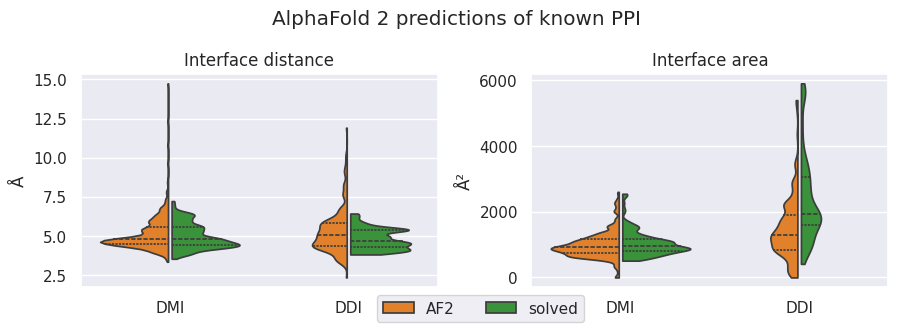

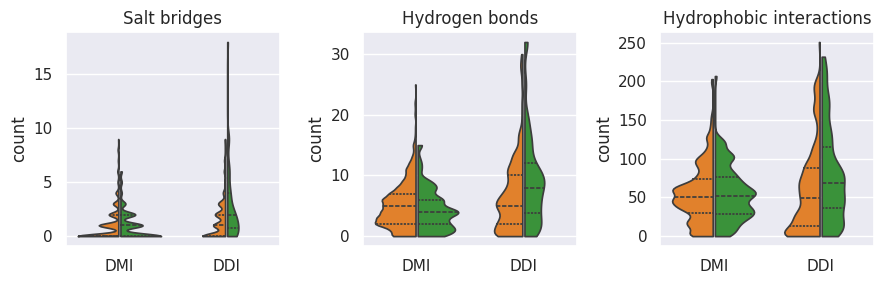

n = 634 / 3170; NA = 0


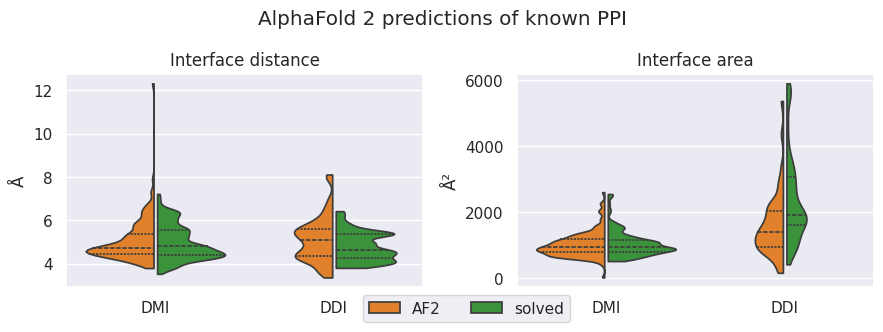

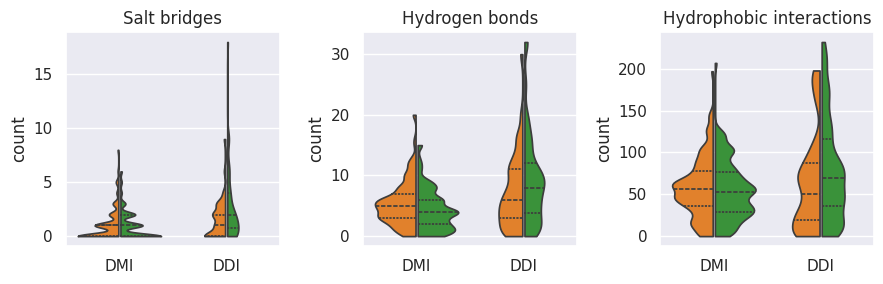

n = 450 / 3170; NA = 920


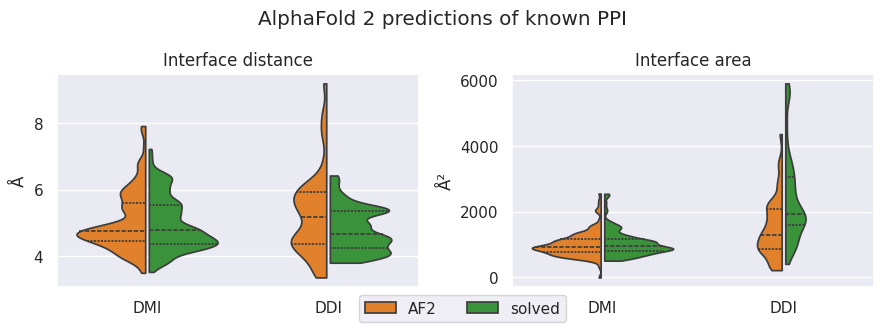

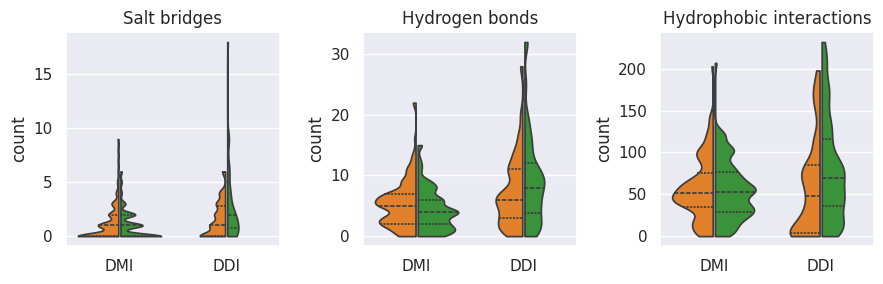

In [9]:
plot_interface_metrics_vs_solved(af_v="AF2", rmsd_filter=False, rank_filter=None, save=True)
plot_interface_metrics_vs_solved(af_v="AF2", rmsd_filter=False, rank_filter="best_ranked", save=True)
plot_interface_metrics_vs_solved(af_v="AF2", rmsd_filter=False, rank_filter="RMSD_peptide", save=True)

In [ ]:
dataAF[(dataAF["RMSD_all_atom_peptide_AF3"] < 2) & (dataAF["model_id"] == "ranked_0") & (dataAF["benchmark_set"] == "known_DMI")]["buried_area_AF3"]

0       602.041
5      1250.340
10      848.152
20      962.633
40     1226.296
45      691.455
55     1099.009
60     1162.085
65     1181.219
75     1222.284
105    1520.381
130    1046.467
135     791.431
140     582.874
175     883.569
195    1470.519
200    1590.575
205    1368.030
210    1829.881
215     679.102
220     767.178
230     761.997
250     848.158
260     892.545
270    1086.726
285     645.434
290     747.353
310     856.017
315    1058.333
345     913.604
355     790.418
360     980.846
370    1680.211
395     685.796
400     847.870
410     877.798
420    1258.148
440     937.619
445    1268.388
450    1001.931
525     788.449
530     606.027
535     761.000
540     669.835
565     749.551
575     844.073
580     963.830
595    1966.162
600     642.140
605    1096.010
610    1126.606
615     600.887
625    1229.526
630     595.035
635    1066.322
640     890.240
650     828.133
660    1070.678
675     886.982
Name: buried_area_AF3, dtype: float64

n = 344 / 3170; NA = 0


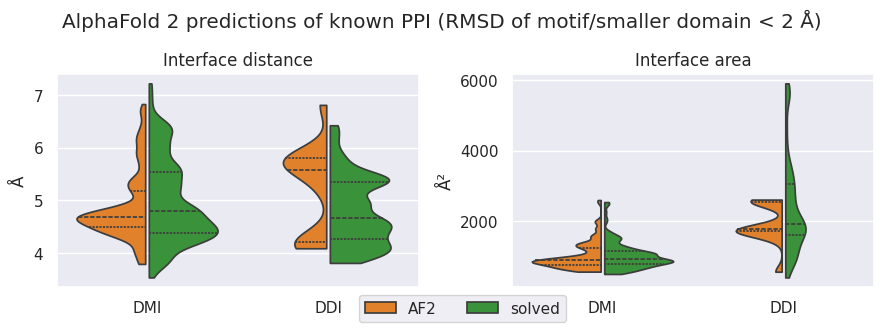

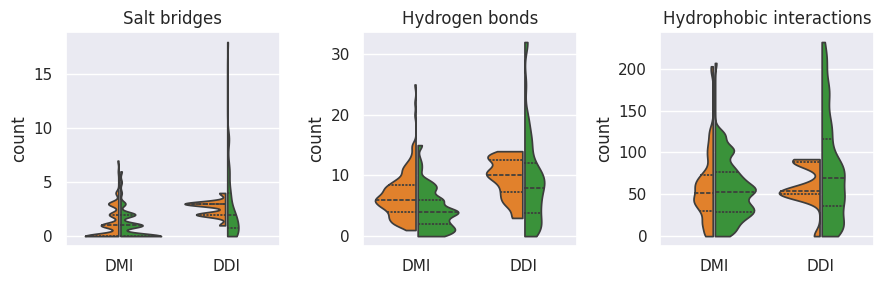

n = 83 / 3170; NA = 0


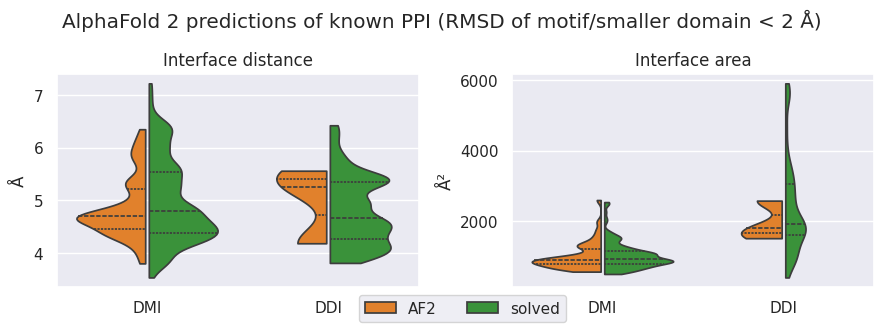

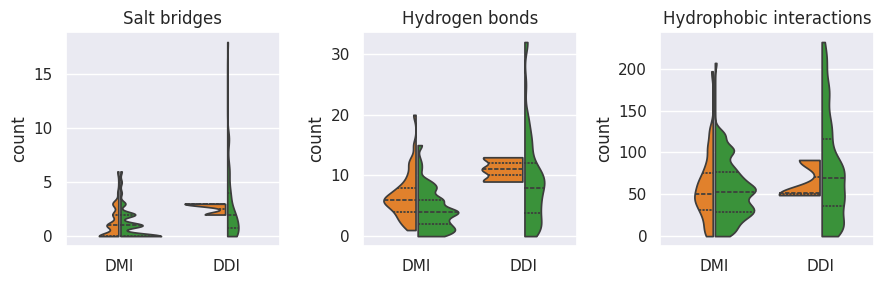

n = 97 / 3170; NA = 0


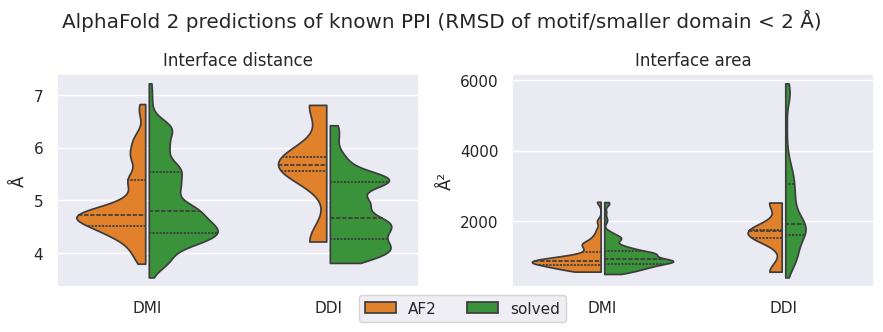

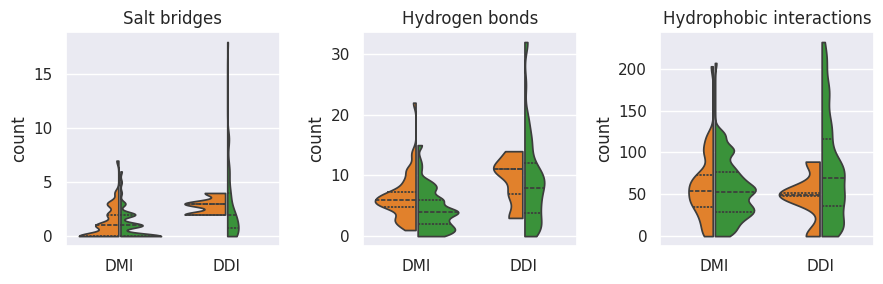

In [ ]:
plot_interface_metrics_vs_solved(af_v="AF2", rmsd_filter=2, rank_filter=None, save=True)
plot_interface_metrics_vs_solved(af_v="AF2", rmsd_filter=2, rank_filter="best_ranked", save=True)
plot_interface_metrics_vs_solved(af_v="AF2", rmsd_filter=2, rank_filter="RMSD_peptide", save=True)

-


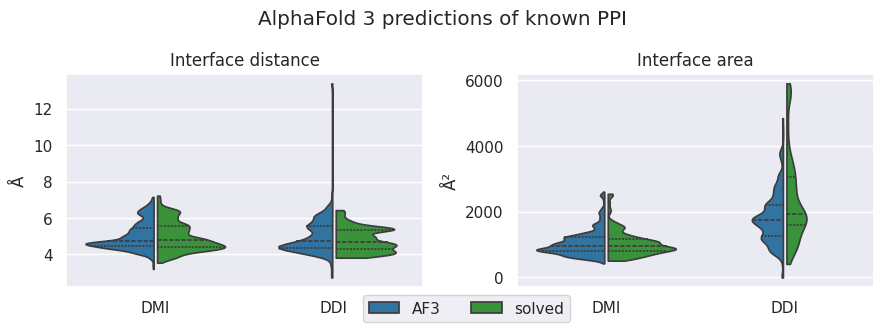

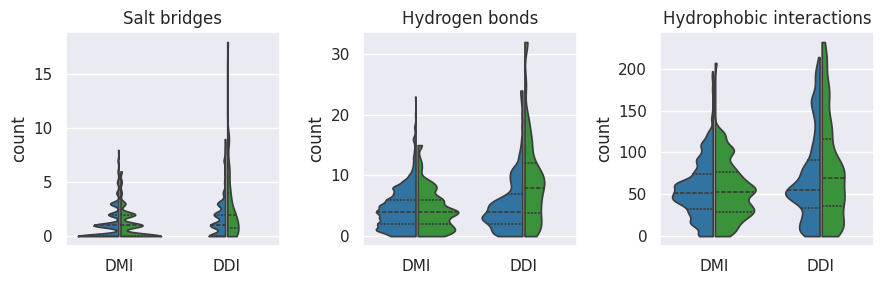

n = 634 / 3170; NA = 0


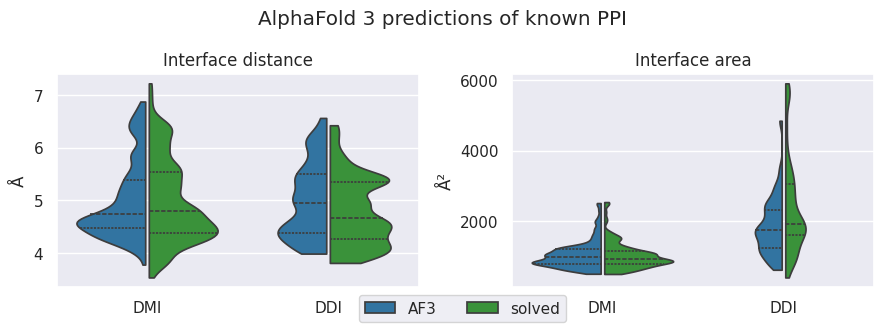

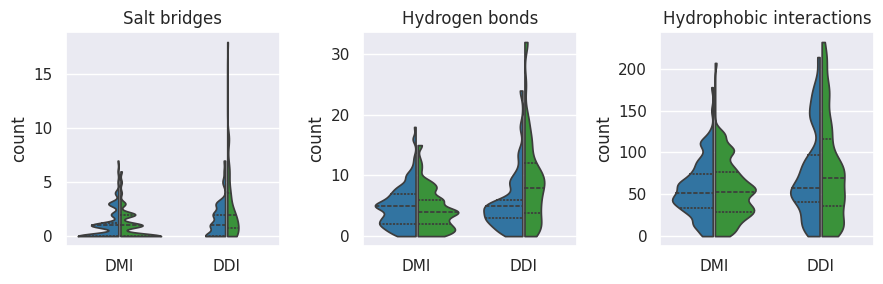

n = 450 / 3170; NA = 920


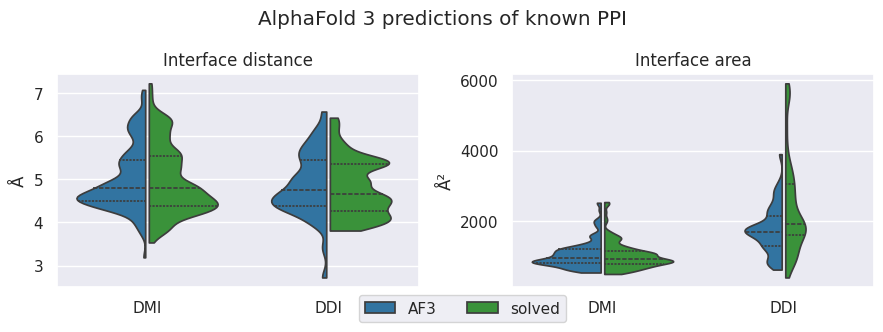

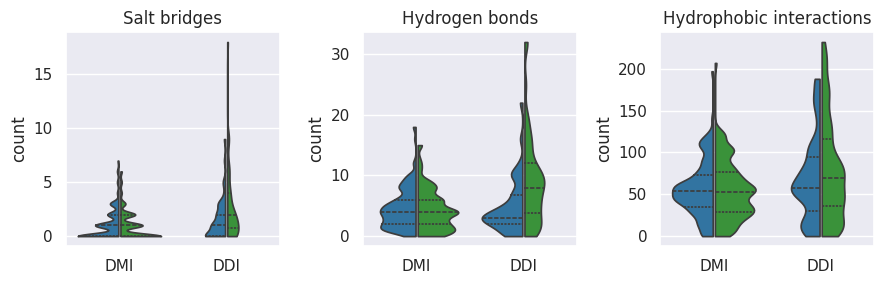

In [11]:
plot_interface_metrics_vs_solved(af_v="AF3", rmsd_filter=False, rank_filter=None, save=True)
plot_interface_metrics_vs_solved(af_v="AF3", rmsd_filter=False, rank_filter="best_ranked", save=True)
plot_interface_metrics_vs_solved(af_v="AF3", rmsd_filter=False, rank_filter="RMSD_peptide", save=True)

### 2 ROC curves

In [12]:
def plot_roc_curves(af_v: Literal["AF2", "AF3"], metric_set: Literal["AF_metrics", "interface_metrics"], rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], rmsd_filter: bool, save: bool, compare_df: pd.DataFrame|None = None):
    sns.set_theme()
    fig, axes = plt.subplots(2, 3, figsize=(10,7))
    fig.suptitle(f"AlphaFold {'3' if af_v == 'AF3' else '2'}")

    classes = {
        "correct sidechain\n(RMSD motif < 2Å)": (-np.inf, 2), 
        "correct backbone\n(RMSD motif < 5Å)": (2, 5), 
        "correct pocket\n(RMSD motif < 15Å)": (5, 15), 
        "wrong pocket\n(RMSD motif >= 15Å)": (15, np.inf)
    }

    if metric_set == "AF_metrics":
        metric_columns = [("model confidence", "model_confidence", "tab:blue") if af_v == "AF2" else ("ranking score", "ranking_score", "royalblue") ,
                        ("Average interface pLDDT", "intf_avg_plddt", "tab:orange"), 
                        ("Domain chain interface pLDDDT", "chainA_intf_avg_plddt", "tab:green"),
                        ("Motif chain interface pLDDT", "chainB_intf_avg_plddt", "tab:purple"),
                        ("pDockQ", "pDockQ", "tab:red"),
                        ("iPAE", "iPAE", "tab:brown", True),
                        ("Residue-residue contact", "num_res_res_contact", "tab:pink"),
                        ("Atom-Atom contact", "num_atom_atom_contact", "tab:gray"),
                        ]
        if af_v == "AF3":
            metric_columns.append(("ipSAE", "ipSAE", "tab:olive"))
    elif metric_set == "interface_metrics":
        metric_columns = [("Interface distance", "min_distance", "tab:blue", True),
                        ("Interface area", "buried_area", "tab:orange"),
                        ("Salt bridges", "salt_bridges", "tab:green"),
                        ("Hydrophobic interactions", "hydrophobic_interactions", "tab:red"),
                        ("Hydrogen bonds", "hbonds", "tab:purple"),
                        ]

    # (display name, column name, color, [reverse], [highlight]) # Note: rever, highlight optional. highligh means
    metric_columns = [[x[0], x[1] + "_"+af_v, x[2] , x[3] if len(x) >= 4 else False, x[4] if len(x) >= 5 else False] for x in metric_columns]

    rows_sets = {
        "known_DMI": dataAF[dataAF["benchmark_set"] == "known_DMI"],
        "known_DDI": dataAF[dataAF["benchmark_set"] == "known_DDI"],
        "mutations1_DMI": dataAF[dataAF["num_mutations"] == 1],
        "mutations2_DMI": dataAF[dataAF["num_mutations"] == 2],
        "random_DMI": dataAF[dataAF["benchmark_set"] == "random_DMI"],
        "random_DDI": dataAF[dataAF["benchmark_set"] == "random_DDI"],
    }
    for c, (b_lower, b_upper) in classes.items():
        rows_sets[c.split("\n")[0]] = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF[f"RMSD_all_atom_peptide_{af_v}"] >= b_lower) & (dataAF[f"RMSD_all_atom_peptide_{af_v}"] < b_upper)]

    #if model_id_filter:
    #    rows_sets = {lbl: df[df["model_id"] == "ranked_0"] for lbl, df in rows_sets.items()}

    #rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]
    if rank_filter == "best_ranked":
        rows_sets = {lbl: df[df["score_rank"] == 1] for lbl, df in rows_sets.items()}
    elif rank_filter is not None:
        rows_sets = {lbl: df[((df[f"{rank_filter}_rank_{af_v}"].isna()) & (df["score_rank"] == 1)) | (df[f"{rank_filter}_rank_{af_v}"] == 1)] for lbl, df in rows_sets.items()}
        rank_filter = rank_filter.replace("_", "") + "_ranked"

    plot_obj = [] # (ax, rows_true, rows_false, (title, [set color]))
    if rmsd_filter:
        plot_obj = [
            (axes[0,0], rows_sets["correct sidechain"], rows_sets["correct backbone"], ("known DMI:\ncorrect sidechain vs. correct backbone", "gold")),
            (axes[0,1], rows_sets["correct sidechain"], rows_sets["correct pocket"], ("known DMI:\ncorrect sidechain vs. correct pocket", "tab:orange")),
            (axes[0,2], rows_sets["correct sidechain"], rows_sets["wrong pocket"], ("known DMI:\ncorrect sidechain vs. wrong pocket", "tab:red")),
            (axes[1,0], rows_sets["correct sidechain"], rows_sets["random_DMI"], ("known DMI & correct sidechain \nvs. randomly paired", "tab:blue")),
        ]
    else:
        plot_obj = [
            (axes[0,0], rows_sets["known_DMI"], rows_sets["mutations1_DMI"], ("known DMI vs.\n1 mutation in motif",)),
            (axes[0,1], rows_sets["known_DMI"], rows_sets["mutations2_DMI"], ("known DMI vs.\n2 mutations in motif",)),
            (axes[0,2], rows_sets["known_DMI"], rows_sets["random_DMI"], ("known DMI vs.\nrandomly paired",)),
            (axes[1,0], rows_sets["known_DDI"], rows_sets["random_DDI"], ("known DDI vs.\nrandomly paired",))
        ]
    axes[1,1].set_title("Area under the ROC curve")
    axes[1,2].set_title("")

    roc_scores = []

    for i, (ax, rows_true, rows_false, title) in enumerate(plot_obj):
        ax: Axes = ax
        for ii, (metric_label, metric_column, color, reverse, highlight) in enumerate(metric_columns):
            if "DDI" in title[0] and metric_column in [f"chainA_intf_avg_plddt_{af_v}", f"chainB_intf_avg_plddt_{af_v}"]: 
                continue
            tr = rows_true[metric_column].dropna()
            fa = rows_false[metric_column].dropna()
            y_true = [1]*len(tr) + [0]*len(fa) if not reverse else [0]*len(tr) + [1]*len(fa)
            y_score = tr.to_list() + fa.to_list()
            p = ax.plot(*roc_curve(y_true, y_score)[0:2], c=color)
            roc_score = roc_auc_score(y_true, y_score)
            title_ol = title[0].replace("\n", " ")
            
            lbl = None
            if i == 0:
                lbl = metric_label
                if compare_df is not None and lbl in ["model confidence", "ranking score"]:
                    lbl = "model confidence (AF2) / ranking score (AF3)"
            c_width = 0.5/len(metric_columns)
            axes[1,1].bar([(1-(1.5*c_width)*(len(metric_columns)-1)/2)+i+ii*1.5*c_width], [roc_score], width=c_width, color=color, label=lbl)

            auroc_compare = None
            if compare_df is not None:
                if metric_label == "ranking score": metric_lbl = "model confidence"
                elif metric_label == "model confidence": metric_lbl = "ranking score"
                else: metric_lbl = metric_label
                row_cdf = compare_df[(compare_df["comparison"] == title_ol) & (compare_df["metric"] == metric_lbl)]
                if len(row_cdf) == 1:
                    axes[1,1].bar([(1-(1.5*c_width)*(len(metric_columns)-1)/2)+i+ii*1.5*c_width], [-row_cdf["AUROC"].item()], width=c_width, color=color, alpha=0.5)
                    auroc_compare = row_cdf["AUROC"].item()
                elif metric_label not in ["ranking score", "model confidence"]:
                    print(f"metric {metric_label} not found in the comparison {title_ol}")
            if auroc_compare is not None:
                roc_scores.append({"comparison": title_ol, "metric": metric_label, "AUROC": round(roc_score, 3), "AUROC compare": round(auroc_compare, 3), "delta AUROC": round(roc_score - auroc_compare, 3)}) # Treat confidence (AF2) and raking score (Af3) in the plot as equal
            else:
                roc_scores.append({"comparison": title_ol, "metric": metric_label, "AUROC": round(roc_score, 3)}) # Treat confidence (AF2) and raking score (Af3) in the plot as equal

        ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label="random predictor")
        ax.set_xlim([0,1])
        ax.set_ylim([0,1])
        ax.set_aspect(1)
        ax.set_xlabel('False Positive Rate\n')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(title[0])
        if rmsd_filter:
            c1 = matplotlib.patches.Circle((0.06, 0.93), 0.03, color="tab:green")
            c2 = matplotlib.patches.Circle((0.14, 0.93), 0.03, color=title[1])
            ax.add_patch(c1)
            ax.add_patch(c2)

    if rmsd_filter:
        axes[1,1].set_xticks([1,2,3,4], ["","","",""])
        for i, pltObj in enumerate(plot_obj):
            c1 = matplotlib.patches.Ellipse((i+0.93,-0.1), 0.1, 0.065, color="tab:green", clip_on=False)
            c2 = matplotlib.patches.Ellipse((i+1.07,-0.1), 0.1, 0.065, color=pltObj[3][1], clip_on=False)
            axes[1,1].add_patch(c1)
            axes[1,1].add_patch(c2)
    else:
        axes[1,1].set_xticks([1,2,3,4], [v[3][-1] for v in plot_obj])
    axes[1,1].set_ylabel("AUROC")
    axes[1,1].plot([0.5, 4.5], [0.5, 0.5], color='navy', lw=1, linestyle='--')
    axes[1,1].plot([0.5, 4.5], [-0.5, -0.5], color='navy', lw=1, linestyle='--')
    axes[1,1].set_xlim([0.5,4.5])
    axes[1,1].set_ylim([0 if compare_df is None else -1,1])
    if compare_df is not None:
        axes[1,1].text(4.6,0.5, f"AlphaFold {3 if af_v == 'AF3' else 2}", rotation=-90, horizontalalignment="center", verticalalignment="center")
        axes[1,1].text(4.6,-0.5, f"AlphaFold {2 if af_v == 'AF3' else 3}", rotation=-90, horizontalalignment="center", verticalalignment="center")
    axes[1,1].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda y,pos:abs(round(y, 3))))
    axes[0,0].legend(frameon=False, loc="lower right")

    fig.tight_layout()

    ax11_pos = axes[1,1].get_position()
    ax11_pos.x1 += 1/3
    axes[1,1].set_position(ax11_pos)
    axes[1,2].set_visible(False)

    if len(metric_columns) >= 6:
        handels, labels = axes[1,1].get_legend_handles_labels()
        labels: list = labels
        if "ipSAE" in labels:
            ni, nf = labels.index("ipSAE"), labels.index("iPAE")
            labels.insert(nf+1, labels.pop(ni))
            handels.insert(nf+1, handels.pop(ni))
        #handels, labels = [x for x in zip(*sorted(zip(handels, labels), key=lambda v: len(v[1]), reverse=True))]
        axes[1,1].legend(handels, labels, loc='upper center', bbox_to_anchor=(0.2, -0.2),
                fancybox=False, shadow=False, ncol=4, frameon=False)
    else:
        axes[1,1].legend(ncol=2, frameon=False)

    fig.text(0.03,0.91, "A", fontsize=18)
    fig.text(0.03,0.45, "B", fontsize=18)
    fig.text(0.355,0.45, "C", fontsize=18)

    if save:
        plt.savefig(f"./plots/{af_v}_ROC_curve{'_new_metrics' if metric_set == 'interface_metrics' else ''}{'_RMSD' if rmsd_filter else ''}{f"_{rank_filter}" if rank_filter else ''}.png", bbox_inches='tight', dpi=600)
    plt.show()

    return(pd.DataFrame(roc_scores))

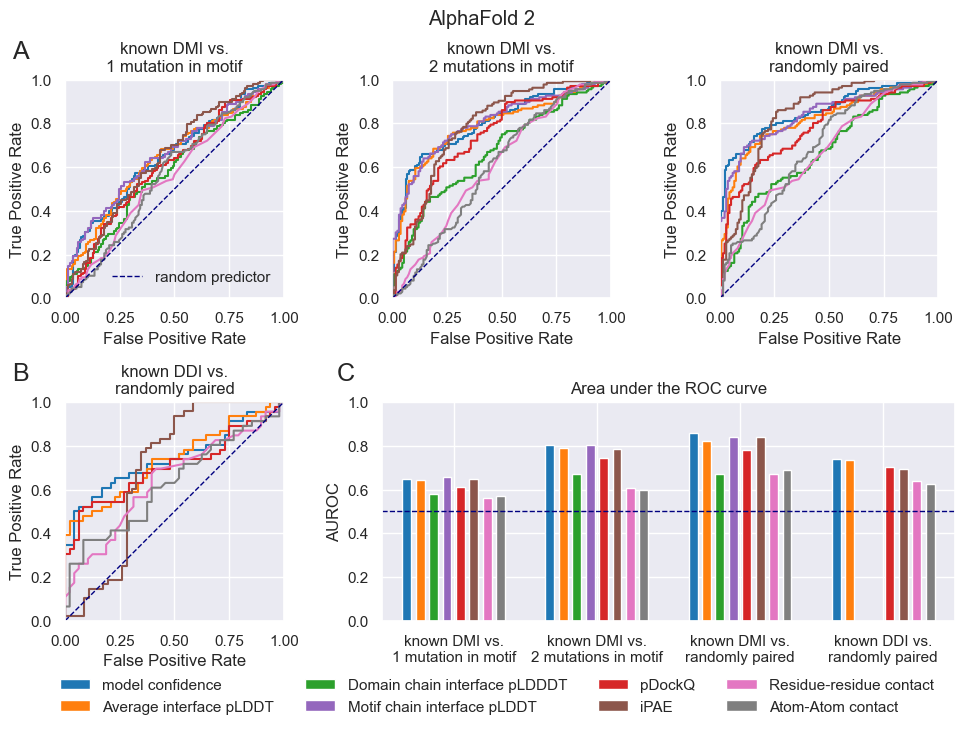

,comparison,metric,AUROC
0,known DMI vs. 1 mutation in motif,model confidence,0.649
1,known DMI vs. 1 mutation in motif,Average interface pLDDT,0.646
2,known DMI vs. 1 mutation in motif,Domain chain interface pLDDDT,0.580
3,known DMI vs. 1 mutation in motif,Motif chain interface pLDDT,0.658
4,known DMI vs. 1 mutation in motif,pDockQ,0.610
5,known DMI vs. 1 mutation in motif,iPAE,0.648
6,known DMI vs. 1 mutation in motif,Residue-residue contact,0.561
7,known DMI vs. 1 mutation in motif,Atom-Atom contact,0.571
8,known DMI vs. 2 mutations in motif,model confidence,0.803
9,known DMI vs. 2 mutations in motif,Average interface pLDDT,0.790


In [13]:
af2_roc_scores = plot_roc_curves(af_v="AF2", metric_set="AF_metrics", rank_filter="best_ranked", rmsd_filter=False, save=True)
af2_roc_scores

metric ipSAE not found in the comparison known DMI vs. 1 mutation in motif
metric ipSAE not found in the comparison known DMI vs. 2 mutations in motif
metric ipSAE not found in the comparison known DMI vs. randomly paired
metric ipSAE not found in the comparison known DDI vs. randomly paired


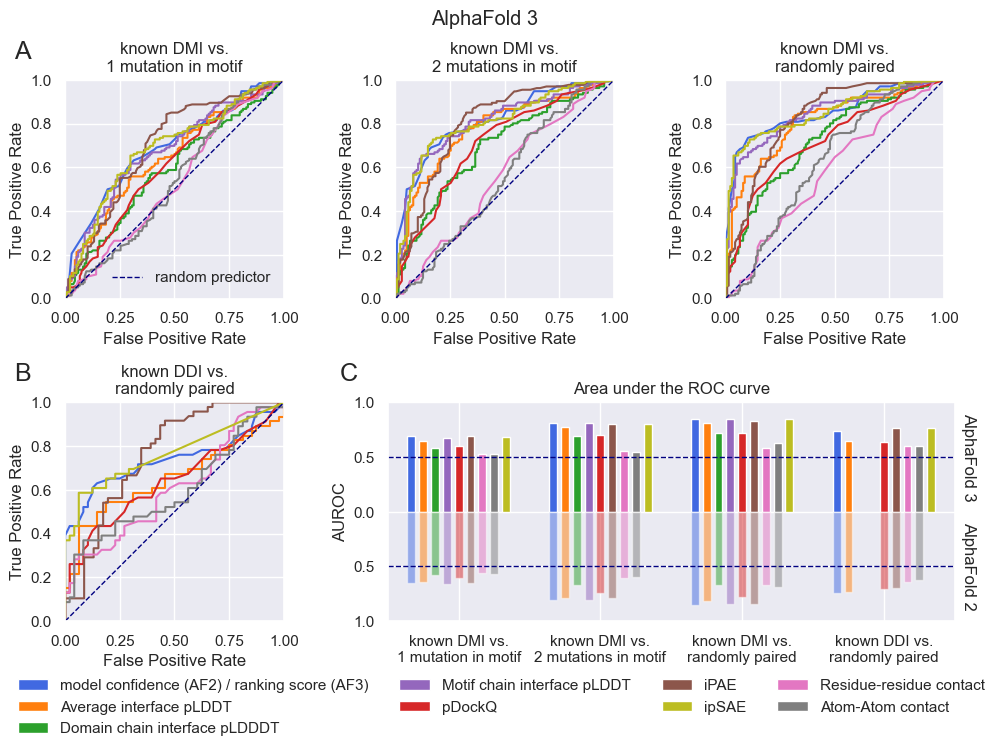

,comparison,metric,AUROC,AUROC compare,delta AUROC
0,known DMI vs. 1 mutation in motif,ranking score,0.689,0.649,0.040
1,known DMI vs. 1 mutation in motif,Average interface pLDDT,0.646,0.646,-0.000
2,known DMI vs. 1 mutation in motif,Domain chain interface pLDDDT,0.585,0.580,0.005
3,known DMI vs. 1 mutation in motif,Motif chain interface pLDDT,0.676,0.658,0.018
4,known DMI vs. 1 mutation in motif,pDockQ,0.602,0.610,-0.008
5,known DMI vs. 1 mutation in motif,iPAE,0.698,0.648,0.050
6,known DMI vs. 1 mutation in motif,Residue-residue contact,0.528,0.561,-0.033
7,known DMI vs. 1 mutation in motif,Atom-Atom contact,0.533,0.571,-0.038
8,known DMI vs. 1 mutation in motif,ipSAE,0.685,NaN,NaN
9,known DMI vs. 2 mutations in motif,ranking score,0.816,0.803,0.013


In [14]:
plot_roc_curves(af_v="AF3", metric_set="AF_metrics", rank_filter="best_ranked", rmsd_filter=False, save=True, compare_df=af2_roc_scores)

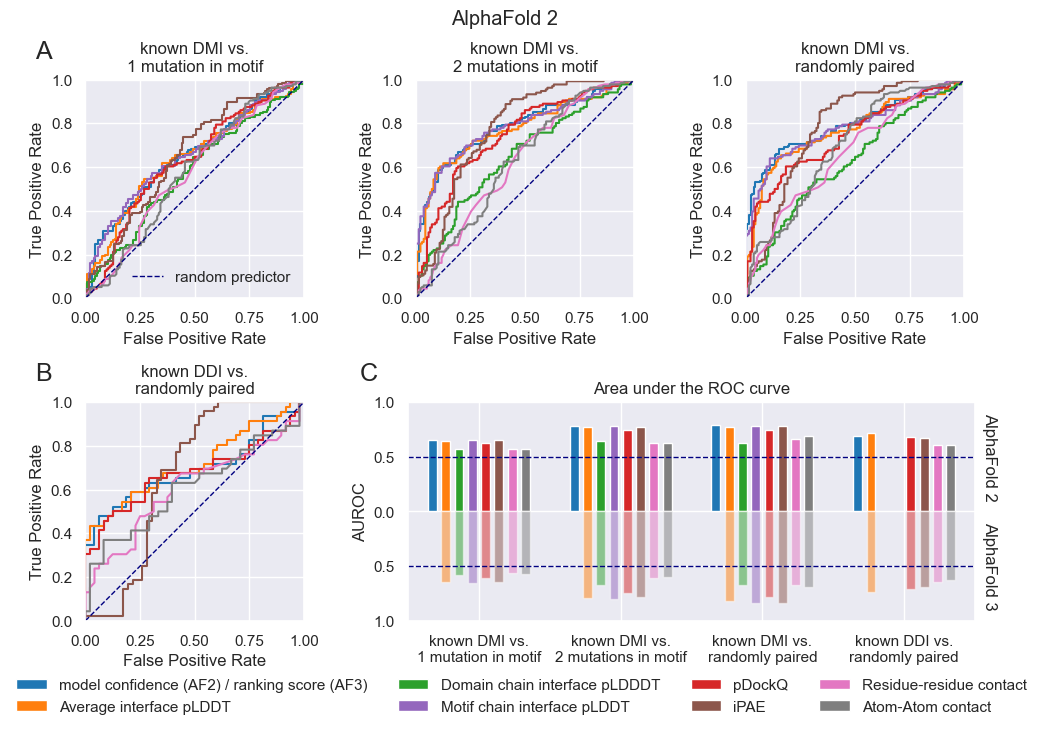

metric ipSAE not found in the comparison known DMI vs. 1 mutation in motif
metric ipSAE not found in the comparison known DMI vs. 2 mutations in motif
metric ipSAE not found in the comparison known DMI vs. randomly paired
metric ipSAE not found in the comparison known DDI vs. randomly paired


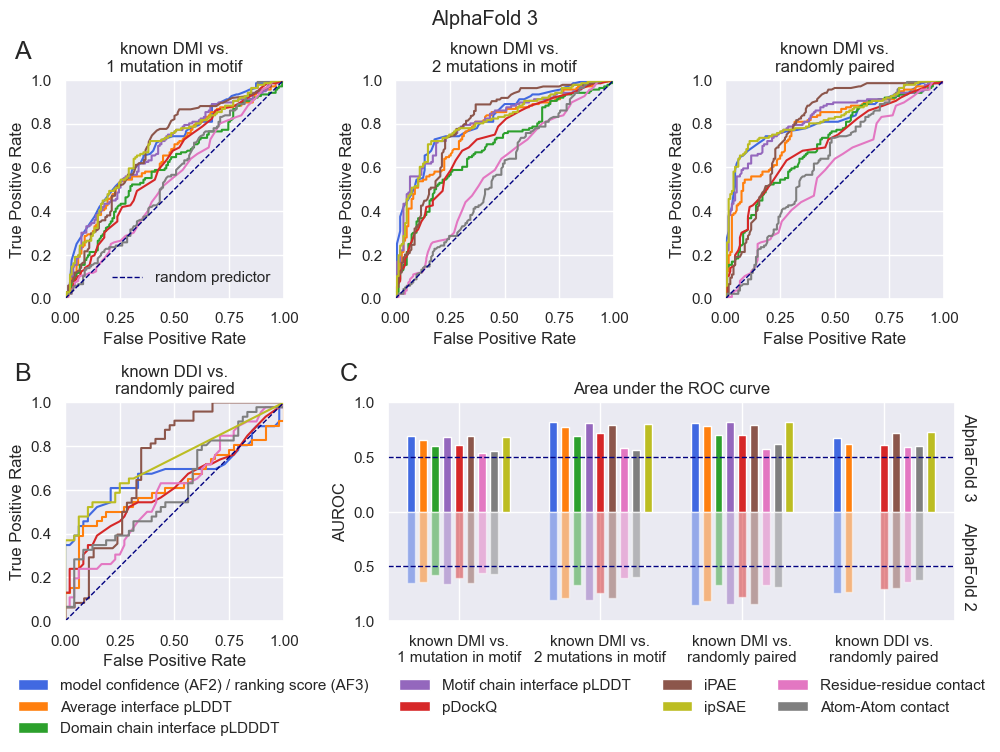

,comparison,metric,AUROC,AUROC compare,delta AUROC
0,known DMI vs. 1 mutation in motif,ranking score,0.694,0.649,0.045
1,known DMI vs. 1 mutation in motif,Average interface pLDDT,0.655,0.646,0.009
2,known DMI vs. 1 mutation in motif,Domain chain interface pLDDDT,0.601,0.580,0.021
3,known DMI vs. 1 mutation in motif,Motif chain interface pLDDT,0.682,0.658,0.024
4,known DMI vs. 1 mutation in motif,pDockQ,0.614,0.610,0.004
5,known DMI vs. 1 mutation in motif,iPAE,0.693,0.648,0.045
6,known DMI vs. 1 mutation in motif,Residue-residue contact,0.537,0.561,-0.024
7,known DMI vs. 1 mutation in motif,Atom-Atom contact,0.555,0.571,-0.016
8,known DMI vs. 1 mutation in motif,ipSAE,0.687,NaN,NaN
9,known DMI vs. 2 mutations in motif,ranking score,0.817,0.803,0.014


In [23]:
plot_roc_curves(af_v="AF2", metric_set="AF_metrics", rank_filter="RMSD_peptide", rmsd_filter=False, save=True, compare_df=af2_roc_scores)
plot_roc_curves(af_v="AF3", metric_set="AF_metrics", rank_filter="RMSD_peptide", rmsd_filter=False, save=True, compare_df=af2_roc_scores)

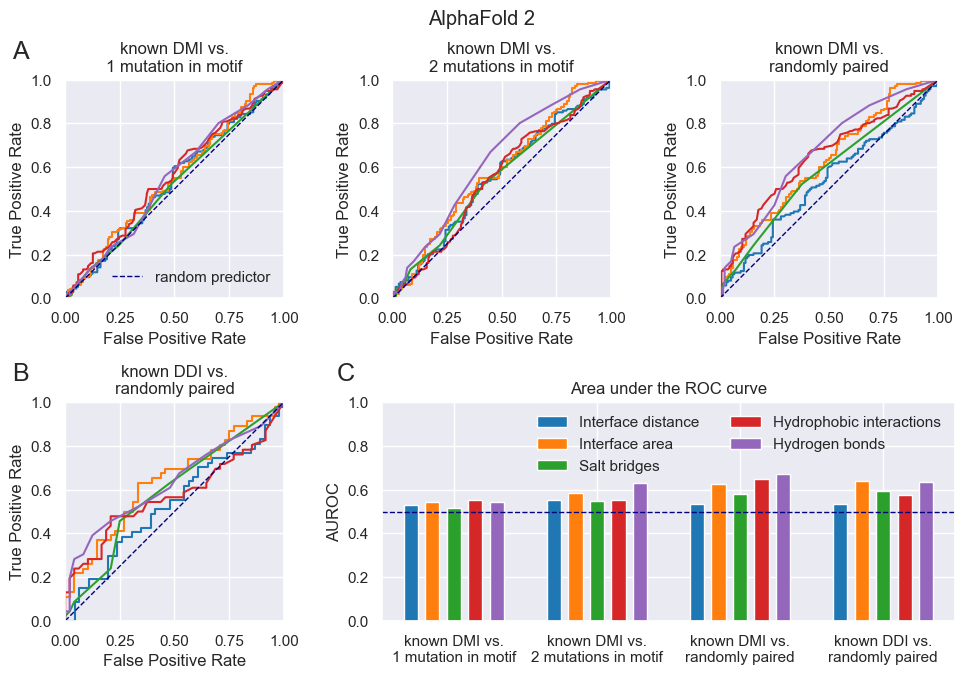

,comparison,metric,AUROC
0,known DMI vs. 1 mutation in motif,Interface distance,0.529
1,known DMI vs. 1 mutation in motif,Interface area,0.545
2,known DMI vs. 1 mutation in motif,Salt bridges,0.515
3,known DMI vs. 1 mutation in motif,Hydrophobic interactions,0.553
4,known DMI vs. 1 mutation in motif,Hydrogen bonds,0.544
5,known DMI vs. 2 mutations in motif,Interface distance,0.554
6,known DMI vs. 2 mutations in motif,Interface area,0.583
7,known DMI vs. 2 mutations in motif,Salt bridges,0.550
8,known DMI vs. 2 mutations in motif,Hydrophobic interactions,0.551
9,known DMI vs. 2 mutations in motif,Hydrogen bonds,0.631


In [16]:
plot_roc_curves(af_v="AF2", metric_set="interface_metrics", rank_filter="best_ranked", rmsd_filter=False, save=True)

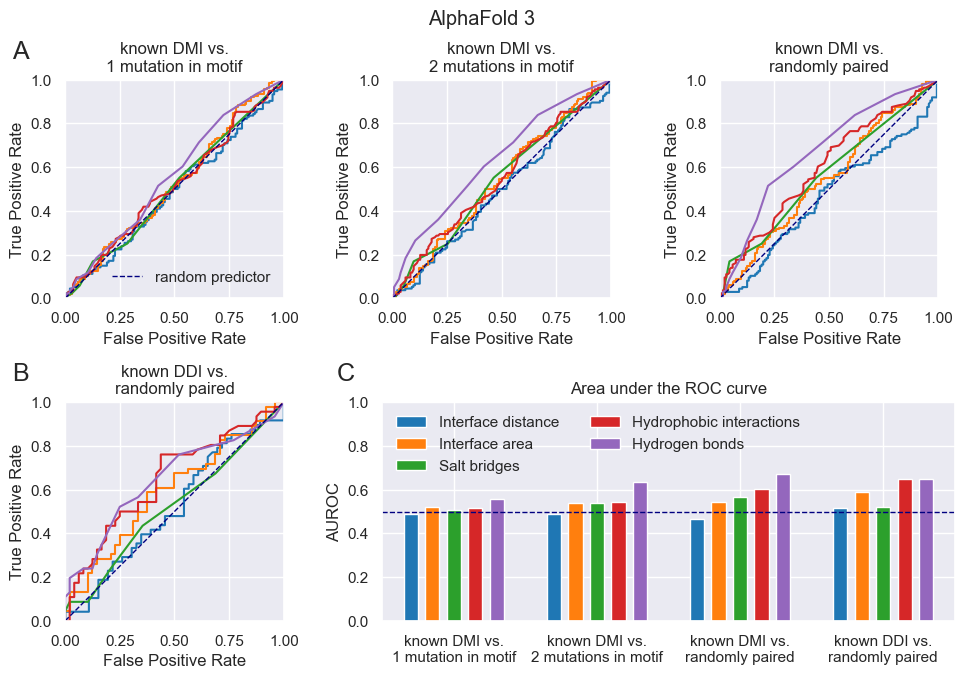

,comparison,metric,AUROC
0,known DMI vs. 1 mutation in motif,Interface distance,0.486
1,known DMI vs. 1 mutation in motif,Interface area,0.520
2,known DMI vs. 1 mutation in motif,Salt bridges,0.508
3,known DMI vs. 1 mutation in motif,Hydrophobic interactions,0.514
4,known DMI vs. 1 mutation in motif,Hydrogen bonds,0.558
5,known DMI vs. 2 mutations in motif,Interface distance,0.491
6,known DMI vs. 2 mutations in motif,Interface area,0.540
7,known DMI vs. 2 mutations in motif,Salt bridges,0.540
8,known DMI vs. 2 mutations in motif,Hydrophobic interactions,0.545
9,known DMI vs. 2 mutations in motif,Hydrogen bonds,0.634


In [17]:
plot_roc_curves(af_v="AF3", metric_set="interface_metrics", rank_filter="best_ranked", rmsd_filter=False, save=True)

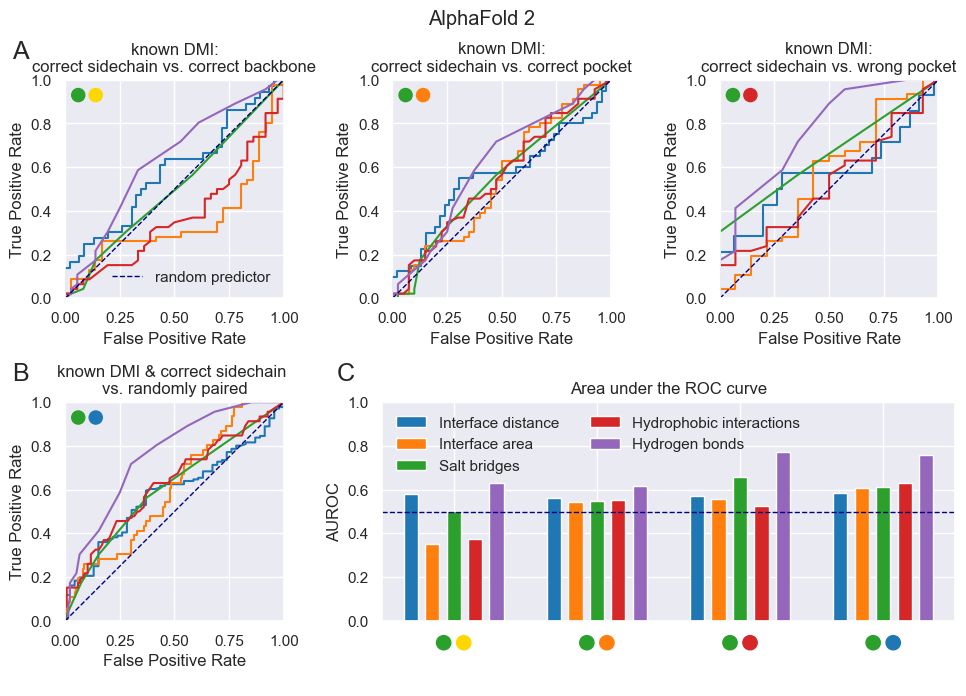

,comparison,metric,AUROC
0,known DMI: correct sidechain vs. correct backbone,Interface distance,0.582
1,known DMI: correct sidechain vs. correct backbone,Interface area,0.353
2,known DMI: correct sidechain vs. correct backbone,Salt bridges,0.501
3,known DMI: correct sidechain vs. correct backbone,Hydrophobic interactions,0.374
4,known DMI: correct sidechain vs. correct backbone,Hydrogen bonds,0.632
5,known DMI: correct sidechain vs. correct pocket,Interface distance,0.561
6,known DMI: correct sidechain vs. correct pocket,Interface area,0.546
7,known DMI: correct sidechain vs. correct pocket,Salt bridges,0.548
8,known DMI: correct sidechain vs. correct pocket,Hydrophobic interactions,0.555
9,known DMI: correct sidechain vs. correct pocket,Hydrogen bonds,0.616


In [18]:
plot_roc_curves(af_v="AF2", metric_set="interface_metrics", rank_filter="best_ranked", rmsd_filter=True, save=True)

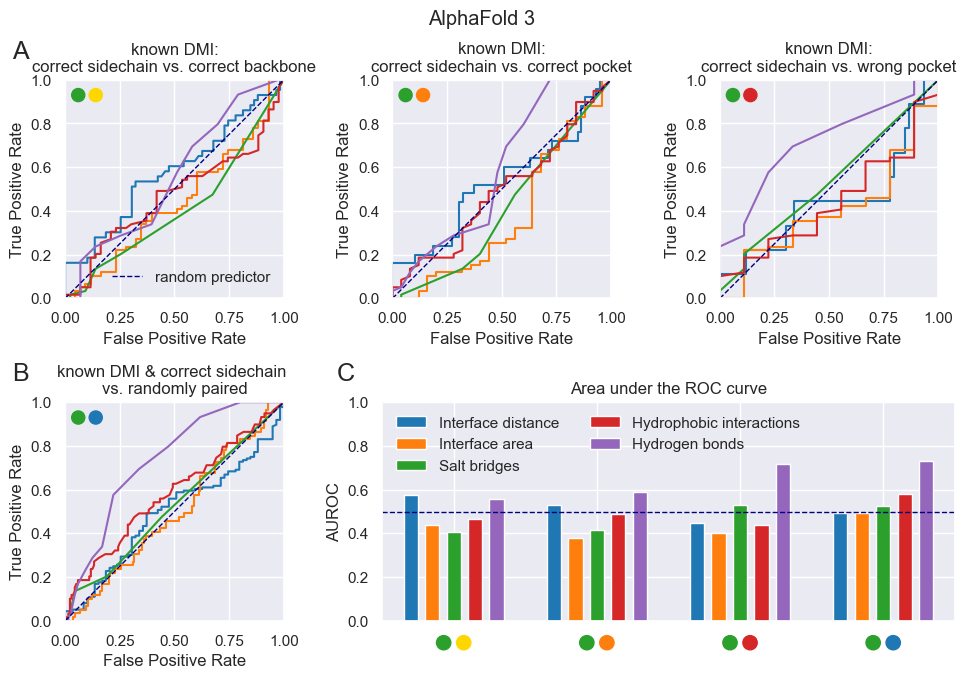

,comparison,metric,AUROC
0,known DMI: correct sidechain vs. correct backbone,Interface distance,0.575
1,known DMI: correct sidechain vs. correct backbone,Interface area,0.436
2,known DMI: correct sidechain vs. correct backbone,Salt bridges,0.407
3,known DMI: correct sidechain vs. correct backbone,Hydrophobic interactions,0.468
4,known DMI: correct sidechain vs. correct backbone,Hydrogen bonds,0.556
5,known DMI: correct sidechain vs. correct pocket,Interface distance,0.529
6,known DMI: correct sidechain vs. correct pocket,Interface area,0.377
7,known DMI: correct sidechain vs. correct pocket,Salt bridges,0.414
8,known DMI: correct sidechain vs. correct pocket,Hydrophobic interactions,0.489
9,known DMI: correct sidechain vs. correct pocket,Hydrogen bonds,0.589


In [19]:
plot_roc_curves(af_v="AF3", metric_set="interface_metrics", rank_filter="best_ranked", rmsd_filter=True, save=True)

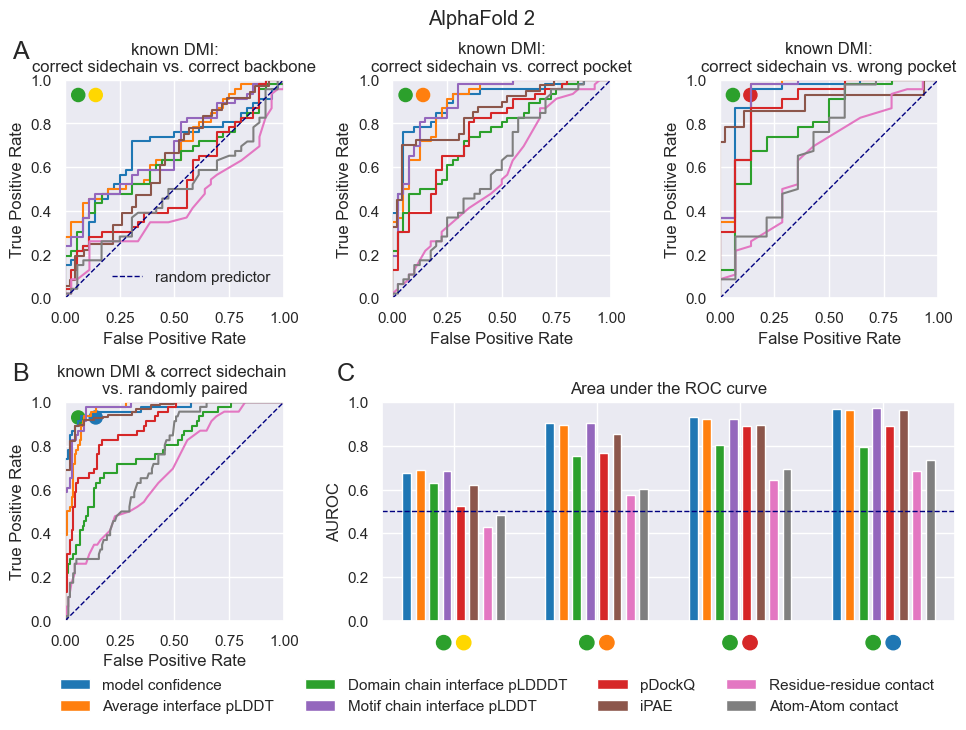

,comparison,metric,AUROC
0,known DMI: correct sidechain vs. correct backbone,model confidence,0.675
1,known DMI: correct sidechain vs. correct backbone,Average interface pLDDT,0.689
2,known DMI: correct sidechain vs. correct backbone,Domain chain interface pLDDDT,0.629
3,known DMI: correct sidechain vs. correct backbone,Motif chain interface pLDDT,0.687
4,known DMI: correct sidechain vs. correct backbone,pDockQ,0.526
5,known DMI: correct sidechain vs. correct backbone,iPAE,0.619
6,known DMI: correct sidechain vs. correct backbone,Residue-residue contact,0.428
7,known DMI: correct sidechain vs. correct backbone,Atom-Atom contact,0.483
8,known DMI: correct sidechain vs. correct pocket,model confidence,0.903
9,known DMI: correct sidechain vs. correct pocket,Average interface pLDDT,0.896


In [20]:
plot_roc_curves(af_v="AF2", metric_set="AF_metrics", rank_filter="best_ranked", rmsd_filter=True, save=True)

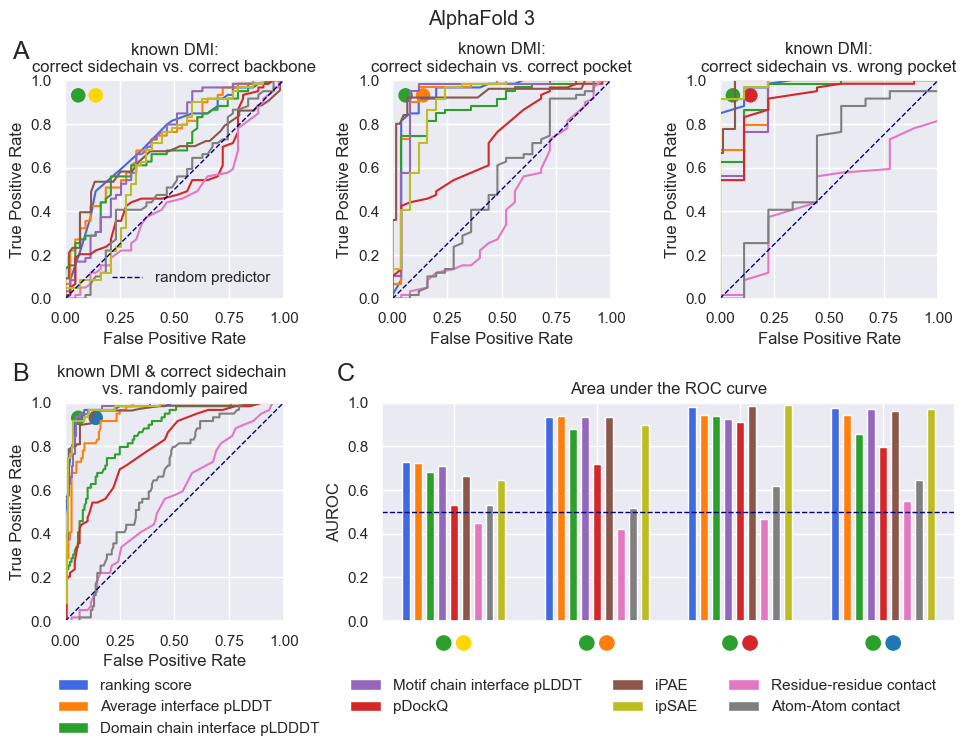

,comparison,metric,AUROC
0,known DMI: correct sidechain vs. correct backbone,ranking score,0.727
1,known DMI: correct sidechain vs. correct backbone,Average interface pLDDT,0.724
2,known DMI: correct sidechain vs. correct backbone,Domain chain interface pLDDDT,0.682
3,known DMI: correct sidechain vs. correct backbone,Motif chain interface pLDDT,0.712
4,known DMI: correct sidechain vs. correct backbone,pDockQ,0.530
5,known DMI: correct sidechain vs. correct backbone,iPAE,0.666
6,known DMI: correct sidechain vs. correct backbone,Residue-residue contact,0.450
7,known DMI: correct sidechain vs. correct backbone,Atom-Atom contact,0.529
8,known DMI: correct sidechain vs. correct backbone,ipSAE,0.644
9,known DMI: correct sidechain vs. correct pocket,ranking score,0.932


In [21]:
plot_roc_curves(af_v="AF3", metric_set="AF_metrics", rank_filter="best_ranked", rmsd_filter=True, save=True)

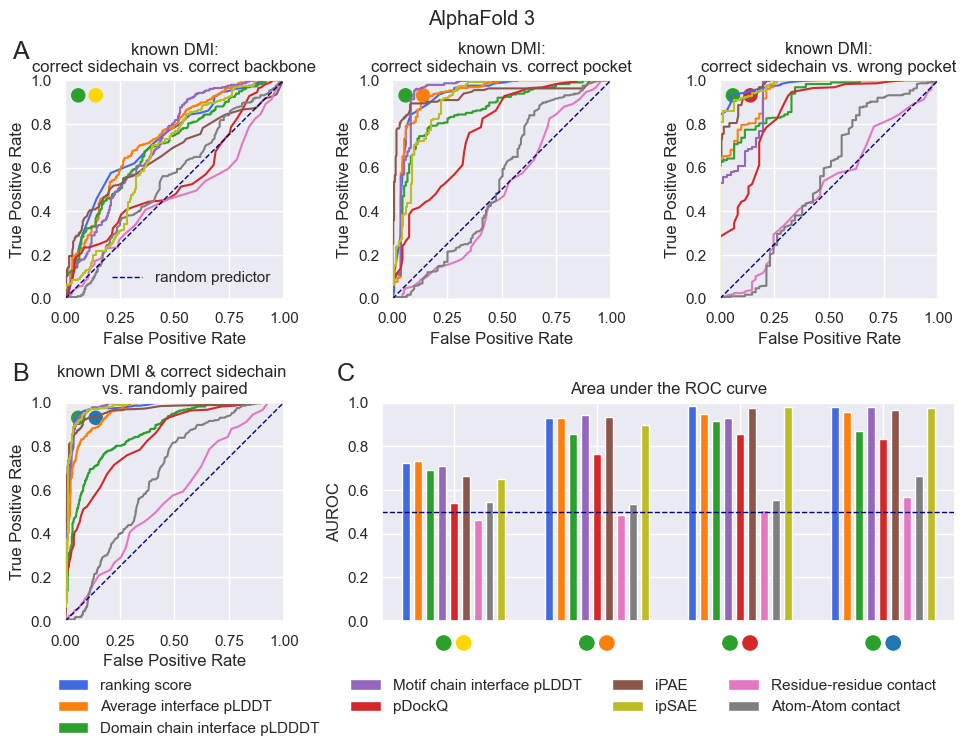

,comparison,metric,AUROC
0,known DMI: correct sidechain vs. correct backbone,ranking score,0.725
1,known DMI: correct sidechain vs. correct backbone,Average interface pLDDT,0.732
2,known DMI: correct sidechain vs. correct backbone,Domain chain interface pLDDDT,0.693
3,known DMI: correct sidechain vs. correct backbone,Motif chain interface pLDDT,0.710
4,known DMI: correct sidechain vs. correct backbone,pDockQ,0.542
5,known DMI: correct sidechain vs. correct backbone,iPAE,0.663
6,known DMI: correct sidechain vs. correct backbone,Residue-residue contact,0.465
7,known DMI: correct sidechain vs. correct backbone,Atom-Atom contact,0.547
8,known DMI: correct sidechain vs. correct backbone,ipSAE,0.652
9,known DMI: correct sidechain vs. correct pocket,ranking score,0.930


In [22]:
plot_roc_curves(af_v="AF3", metric_set="AF_metrics", rank_filter=None, rmsd_filter=True, save=True)

#### 2b normalization ROC curves

In [ ]:
# Add normalized columns

def plot_roc_curve_normalized(af_v: Literal["AF2", "AF3"]):

for c in ["num_atom_atom_contacts", "num_res_res_contacts", "num_chainA_intf_res", "num_chainB_intf_res", "buried_area"]:


### 3 RMSD Classifications

RMSD motif distribution

In [ ]:
def plot_rmsd_dist(ax, af_v: Literal["AF2", "AF3"], rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], title:bool):
    sns.set_theme()
    mpl.rcParams['font.family'] = 'DejaVu Sans'
    data_mask = True
    if rank_filter == "best_ranked":
        data_mask = data_mask & (dataAF[f"score_rank"] == 1)
    elif rank_filter is not None:
        data_mask = data_mask & (dataAF[f"{rank_filter}_rank_{af_v}"] == 1)
    d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask][f"RMSD_all_atom_peptide_{af_v}"]
    p = sns.violinplot(ax=ax, data=d, bw_adjust=0.5, cut=0)
    if title:
        p.set_title(f"{af_v} predictions of 136 DMIs")
    p.set_ylabel("motif RMSD [Å]")
    ax.set_ylim(p.get_ylim())
    ax.set_xlim([-0.45,0.53])
    #sns.reset_defaults() # Needed as bar plot is otherwise with gaps
    ax.bar([0.5], [2], bottom=0, width=0.1, label="Correct sidechain", color="tab:green")
    ax.bar([0.5], [5], bottom=2, width=0.1, label="Correct backbone", color="gold")
    ax.bar([0.5], [15], bottom=5, width=0.1, label="Correct backbone", color="tab:orange")
    ax.bar([0.5], [ax.get_ylim()[1]], bottom=15, width=0.1, label="Correct backbone", color="tab:red")
    ax.set_aspect(1/ax.get_ylim()[1]/0.75)
    print(f"Max RMSD: {np.max(d):1.3f} A")

In [ ]:
def plot_classifications(ax, af_v: Literal["AF2", "AF3"], rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], lbl_mode: Literal["full", "short", "none"], long_title: bool):
    sns.reset_defaults()
    mpl.rcParams['font.family'] = 'DejaVu Sans'
    classes = {
        "Correct sidechain\n(RMSD motif < 2Å)": (-np.inf, 2), 
        "Correct backbone\n(RMSD motif < 5Å)": (2, 5), 
        "Correct pocket\n(RMSD motif < 15Å)": (5, 15), 
        "Wrong pocket\n(RMSD motif >= 15Å)": (15, np.inf)
    }
    d = {}
    data_mask = True
    #if model_filter:
    #    data_mask &= (dataAF["model_id"] == "ranked_0")
    #rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]
    if rank_filter == "best_ranked":
        data_mask = data_mask & (dataAF[f"score_rank"] == 1)
    elif rank_filter is not None:
        data_mask = data_mask & (dataAF[f"{rank_filter}_rank_{af_v}"] == 1)

    for label, ra in classes.items():
        if lbl_mode == "short":
            label = label.split("\n")[0].replace(" ", "\n")
        d[label] = len(dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask & (dataAF[f"RMSD_all_atom_peptide_{af_v}"] >= ra[0]) & (dataAF[f"RMSD_all_atom_peptide_{af_v}"] < ra[1])])
    ax.pie(list(d.values()), autopct=lambda v: f"{v/100*sum(d.values()):.0f}\n({v:1.0f}%)", startangle=90, counterclock=False, colors=["tab:green", "gold", "tab:orange", "tab:red"], labels=(d.keys() if lbl_mode != "none" else None))
    if long_title:
        ax.set_title(f"136 AlphaFold {'3' if af_v == 'AF3' else '2'} DMI predictions classified")
    else:
        ax.set_title(f"AlphaFold {'3' if af_v == 'AF3' else '2'}")

def plot_af2_vs_af3(save:bool, rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]):
    sns.set_theme()
    mpl.rcParams['font.family'] = 'DejaVu Sans'
    fig, axes = plt.subplots(1,3, figsize=(9,3.5))
    plot_classifications(axes[0], af_v="AF2", rank_filter=rank_filter, lbl_mode="short", long_title=False)
    plot_classifications(axes[1], af_v="AF3", rank_filter=rank_filter, lbl_mode="none", long_title=False)
    plot_rmsd_dist(axes[2], af_v="AF3", rank_filter=rank_filter, title=True)
    axes[0].set_anchor("S")
    axes[1].set_anchor("S")
    axes[2].set_aspect(1/30)
    plt.tight_layout()
    fig.text(0.36, 0.86, "136 known DMI", fontsize=16, horizontalalignment="center")
    sns.reset_defaults()
    axes[0].annotate("", xytext=(1.5, 1.5), xy=(0.7, 0.7), arrowprops=dict(arrowstyle="->"))
    axes[1].annotate("", xytext=(-1.5, 1.5), xy=(-0.7, 0.7), arrowprops=dict(arrowstyle="->"))
    fig.text(0.04,0.91, "A", fontsize=18)
    fig.text(0.67,0.91, "B", fontsize=18)
    if save:
        plt.savefig(f"./plots/AF2_vs_AF3_DMI_RMSD_motif{f'_{rank_filter.replace("_ranked", "")}_ranked' if rank_filter else ''}.png", bbox_inches='tight', dpi=600)
    plt.show()


def plot_af2_DMI_RMSD(save:bool, rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]):
    fig, axes = plt.subplots(1,2, figsize=(9,3.5))
    plot_classifications(axes[0], af_v="AF2", rank_filter=rank_filter, lbl_mode="full", long_title=True)
    plot_rmsd_dist(axes[1], af_v="AF2", rank_filter=rank_filter, title=True)
    plt.tight_layout()
    fig.text(0.04,0.91, "A", fontsize=18)
    fig.text(0.6,0.91, "B", fontsize=18)
    if save:
        plt.savefig(f"./plots/AF2_knownDMI_RMSD_motif{f'_{rank_filter.replace("_ranked", "")}_ranked' if rank_filter else ''}.png", bbox_inches='tight', dpi=600)
    plt.show()

Max RMSD: 44.644 A


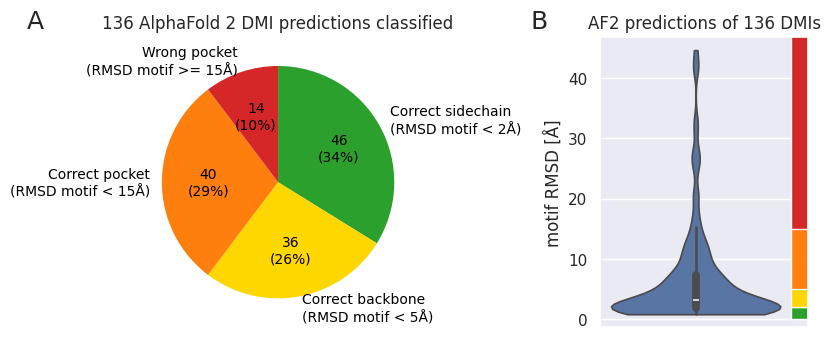

In [ ]:
plot_af2_DMI_RMSD(save=True, rank_filter="best_ranked")

Max RMSD: 44.354 A


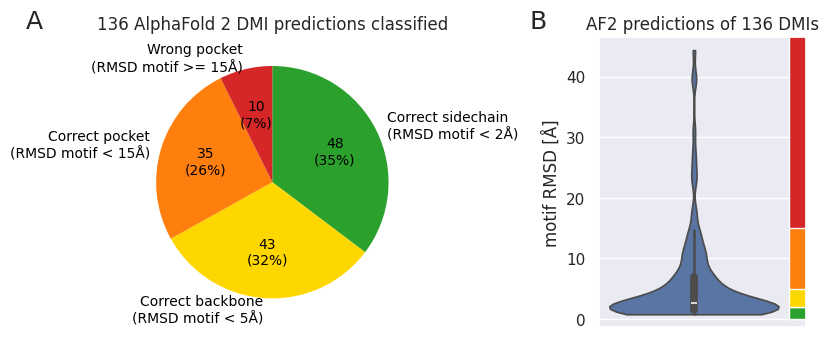

In [ ]:
plot_af2_DMI_RMSD(save=True, rank_filter="RMSD_peptide")

Max RMSD: 184.071 A


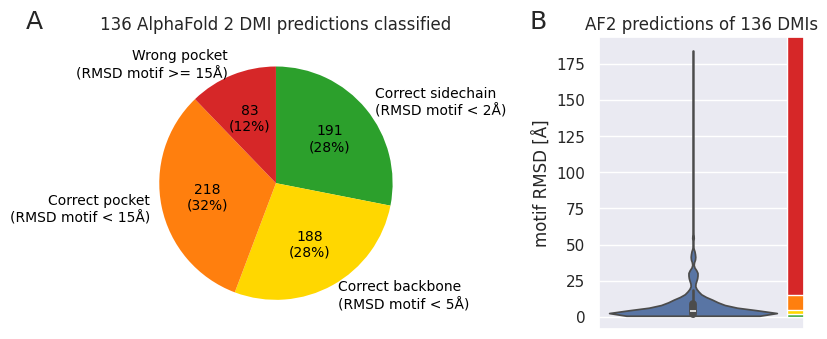

In [ ]:
plot_af2_DMI_RMSD(save=True, rank_filter=None)

Max RMSD: 44.644 A


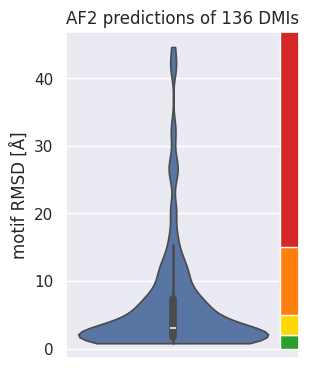

In [ ]:
plt.figure(figsize=(3,5))
plot_rmsd_dist(plt.gca(), af_v="AF2", rank_filter="best_ranked", title=True)
plt.show()

Max RMSD: 41.517 A


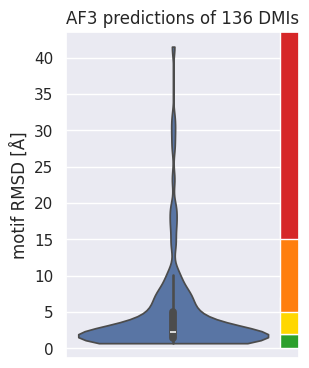

In [ ]:
plt.figure(figsize=(3,5))
plot_rmsd_dist(plt.gca(), af_v="AF3", rank_filter="best_ranked", title=True)
plt.show()

Max RMSD: 44.644 A
Max RMSD: 41.517 A


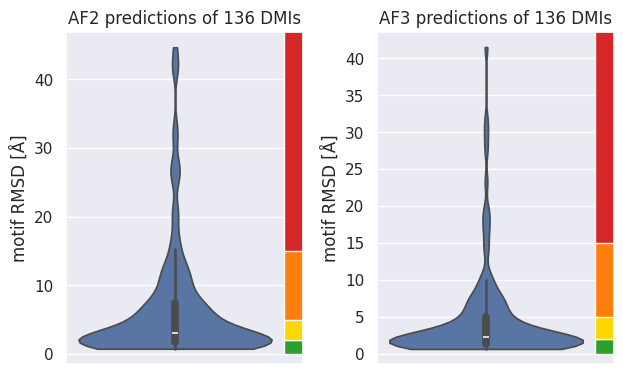

In [ ]:
fig, axes = plt.subplots(1,2)
plot_rmsd_dist(axes[0], af_v="AF2", rank_filter="best_ranked", title=True)
plot_rmsd_dist(axes[1], af_v="AF3", rank_filter="best_ranked", title=True)
plt.tight_layout()
plt.show()

Max RMSD: 41.517 A


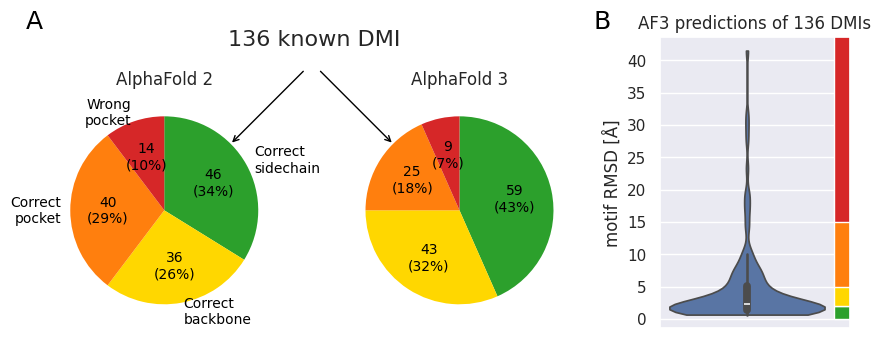

In [ ]:
plot_af2_vs_af3(save=True, rank_filter="best_ranked")

Max RMSD: 34.756 A


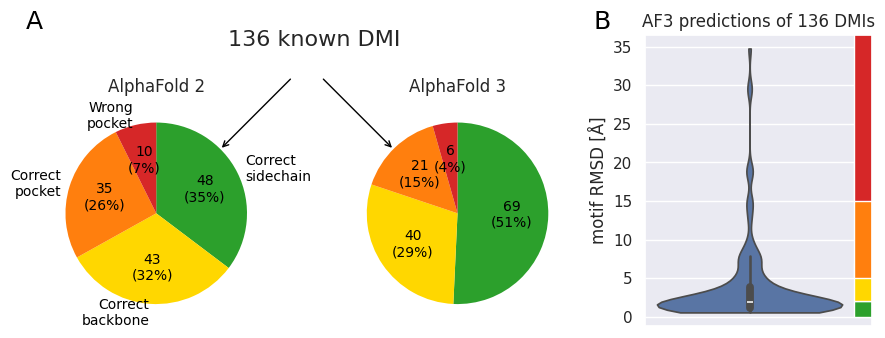

In [ ]:
plot_af2_vs_af3(save=True, rank_filter="RMSD_peptide")

Overall performance

In [ ]:
def eval_set(metric:Literal["RMSD_all_atom", "RMSD_all_atom_peptide", "RMSD_domain", "DockQ"], rank_filter: None|str|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], rmsd_filter: float|None, violinplot: bool):
    data = {}
    def _print(benchmark_set, af_v):
        nonlocal data_mask_AF2, data_mask_AF3, metric, rank_filter
        data_mask = data_mask_AF3 if af_v == "AF3" else data_mask_AF2
        d = dataAF[(dataAF["benchmark_set"] == benchmark_set) & data_mask][metric+"_"+af_v]
        data[f"{af_v} {benchmark_set}"] = list(d)
        print(f"\t{af_v} median {benchmark_set}{(' (ranked by %s)' % rank_filter) if rank_filter else ''}: {np.nanmedian(d):1.3f}, Q1 = {np.quantile(d, q=0.25):1.3f}, Q3 = {np.quantile(d, q=0.75):1.3f}")

    data_mask_AF2 = np.full(len(dataAF), fill_value=True)
    data_mask_AF3 = np.full(len(dataAF), fill_value=True)
    if rank_filter == "best_ranked":
        data_mask_AF2 = data_mask_AF2 & (dataAF[f"score_rank"] == 1)
        data_mask_AF3 = data_mask_AF2
    elif rank_filter is not None:
        data_mask_AF2 = data_mask_AF2 & (dataAF[f"{rank_filter}_rank_AF2"] == 1)
        data_mask_AF3 = data_mask_AF3 & (dataAF[f"{rank_filter}_rank_AF3"] == 1)
    if rmsd_filter:
        data_mask_AF2 &= dataAF["RMSD_all_atom_peptide"] <= rmsd_filter
        data_mask_AF3 &= dataAF["RMSD_all_atom_peptide"] <= rmsd_filter

    
    print(f"{metric}" + (f"(RMSD <= {rmsd_filter:1.1f})" if rmsd_filter else ""))
    _print("known_DMI", "AF2")
    _print("known_DMI", "AF3")
    _print("known_DDI", "AF2")
    _print("known_DDI", "AF3")
    if violinplot:
        sns.catplot(data)
        plt.show()


In [ ]:
eval_set("RMSD_all_atom", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)
eval_set("DockQ", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)
eval_set("RMSD_all_atom_peptide", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)
eval_set("RMSD_domain", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)

RMSD_all_atom
	AF2 median known_DMI (ranked by RMSD_peptide): 1.913, Q1 = 1.476, Q3 = 3.234
	AF3 median known_DMI (ranked by RMSD_peptide): 1.727, Q1 = 1.165, Q3 = 2.808
	AF2 median known_DDI (ranked by RMSD_peptide): 5.623, Q1 = 1.915, Q3 = 11.584
	AF3 median known_DDI (ranked by RMSD_peptide): 4.504, Q1 = 1.945, Q3 = 10.624
DockQ
	AF2 median known_DMI (ranked by RMSD_peptide): 0.817, Q1 = 0.508, Q3 = 0.909
	AF3 median known_DMI (ranked by RMSD_peptide): 0.886, Q1 = 0.709, Q3 = 0.949
	AF2 median known_DDI (ranked by RMSD_peptide): 0.248, Q1 = 0.049, Q3 = 0.676
	AF3 median known_DDI (ranked by RMSD_peptide): 0.331, Q1 = 0.054, Q3 = 0.680
RMSD_all_atom_peptide
	AF2 median known_DMI (ranked by RMSD_peptide): 2.704, Q1 = 1.539, Q3 = 6.970
	AF3 median known_DMI (ranked by RMSD_peptide): 1.962, Q1 = 1.141, Q3 = 3.837
	AF2 median known_DDI (ranked by RMSD_peptide): 9.535, Q1 = 4.482, Q3 = 23.688
	AF3 median known_DDI (ranked by RMSD_peptide): 8.707, Q1 = 4.220, Q3 = 25.342
RMSD_domain
	AF2 m

In [ ]:
eval_set("RMSD_all_atom", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)
eval_set("DockQ", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)
eval_set("RMSD_all_atom_peptide", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)
eval_set("RMSD_domain", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)

RMSD_all_atom
	AF2 median known_DMI (ranked by best_ranked): 1.979, Q1 = 1.498, Q3 = 3.553
	AF3 median known_DMI (ranked by best_ranked): 1.769, Q1 = 1.225, Q3 = 3.121
	AF2 median known_DDI (ranked by best_ranked): 6.124, Q1 = 2.218, Q3 = 15.697
	AF3 median known_DDI (ranked by best_ranked): 4.647, Q1 = 2.087, Q3 = 16.421
DockQ
	AF2 median known_DMI (ranked by best_ranked): 0.798, Q1 = 0.399, Q3 = 0.902
	AF3 median known_DMI (ranked by best_ranked): 0.855, Q1 = 0.654, Q3 = 0.944
	AF2 median known_DDI (ranked by best_ranked): 0.255, Q1 = 0.029, Q3 = 0.675
	AF3 median known_DDI (ranked by best_ranked): 0.311, Q1 = 0.024, Q3 = 0.676
RMSD_all_atom_peptide
	AF2 median known_DMI (ranked by best_ranked): 3.073, Q1 = 1.757, Q3 = 7.380
	AF3 median known_DMI (ranked by best_ranked): 2.254, Q1 = 1.349, Q3 = 5.029
	AF2 median known_DDI (ranked by best_ranked): 13.156, Q1 = 4.847, Q3 = 33.844
	AF3 median known_DDI (ranked by best_ranked): 12.109, Q1 = 5.279, Q3 = 37.097
RMSD_domain
	AF2 median know

In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")]
print(f"mean RMSD motif of AF2 known DMI: {np.nanmean(d["RMSD_all_atom_peptide_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"mean RMSD motif of AF3 known DMI: {np.nanmean(d["RMSD_all_atom_peptide_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"median RMSD motif of AF2 known DMI: {np.nanmedian(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"median RMSD motif of AF3 known DMI: {np.nanmedian(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"AF2 overall mean RMSD: {np.nanmean(d["RMSD_all_atom_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall mean RMSD: {np.nanmean(d["RMSD_all_atom_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF3"]):1.3f}")

print(f"AF2 overall median RMSD: {np.nanmedian(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall median RMSD: {np.nanmedian(d["RMSD_all_atom_AF3"]):1.3f}")

mean RMSD motif of AF2 known DMI: 6.624 +- 8.426
mean RMSD motif of AF3 known DMI: 4.671 +- 6.404
median RMSD motif of AF2 known DMI: 3.073
median RMSD motif of AF3 known DMI: 2.254
AF2 overall mean RMSD: 2.743 +- 1.789
AF3 overall mean RMSD: 2.385 +- 1.662
AF2 overall median RMSD: 1.979
AF3 overall median RMSD: 1.769


In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI")]
print(f"mean RMSD motif of AF2 known DMI (all): {np.nanmean(d["RMSD_all_atom_peptide_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"mean RMSD motif of AF3 known DMI (all): {np.nanmean(d["RMSD_all_atom_peptide_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"median RMSD motif of AF2 known DMI (all): {np.nanmedian(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"median RMSD motif of AF3 known DMI (all): {np.nanmedian(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"AF2 overall mean RMSD (all): {np.nanmean(d["RMSD_all_atom_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall mean RMSD (all): {np.nanmean(d["RMSD_all_atom_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF3"]):1.3f}")

print(f"AF2 overall median RMSD (all): {np.nanmedian(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall median RMSD (all): {np.nanmedian(d["RMSD_all_atom_AF3"]):1.3f}")

mean RMSD motif of AF2 known DMI (all): 8.242 +- 13.966
mean RMSD motif of AF3 known DMI (all): 5.554 +- 8.025
median RMSD motif of AF2 known DMI (all): 4.217
median RMSD motif of AF3 known DMI (all): 2.443
AF2 overall mean RMSD (all): 3.007 +- 2.692
AF3 overall mean RMSD (all): 2.636 +- 2.847
AF2 overall median RMSD (all): 2.151
AF3 overall median RMSD (all): 1.777


In [ ]:
d.columns

Index(['model_preset', 'benchmark_set', 'prediction_name', 'model_id',
       'ranking_score_AF3', 'chainA_length', 'chainB_length', 'chainA_id',
       'chainB_id', 'chainA_start', 'chainA_end', 'chainB_start', 'chainB_end',
       'PDB_id', 'ELM_instance', 'DDI_pfam_id', 'PDB_id_random_paired',
       'ELM_instance_random_paired', 'DDI_pfam_id_random_paired',
       'sequence_initial', 'sequence_mutated', 'num_mutations',
       'fraction_disordered', 'has_clash', 'iptm', 'ptm',
       'chainA_intf_avg_plddt_AF3', 'chainB_intf_avg_plddt_AF3',
       'intf_avg_plddt_AF3', 'num_chainA_intf_res_AF3',
       'num_chainB_intf_res_AF3', 'num_res_res_contact_AF3',
       'num_atom_atom_contact_AF3', 'align_score_domain_AF3',
       'num_align_atoms_domain_AF3', 'num_align_resi_domain_AF3',
       'RMSD_domain_AF3', 'RMSD_backbone_peptide_AF3',
       'RMSD_all_atom_peptide_AF3', 'RMSD_all_atom_AF3', 'iPAE_AF3',
       'pDockQ_AF3', 'chains_flipped', 'model_path', 'DockQ_AF3', 'iRMSD_AF3',
 

In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI")]
print(f"DockQ metric: {np.nanmedian(d["DockQ_AF2"]):1.3f}")

AF2 overall median RMSD (all): 0.729


In [ ]:
# DDI
d = dataAF[(dataAF["benchmark_set"] == "known_DDI") & (dataAF["model_id"] == "ranked_0")]

print(f"mean RMSD motif of AF2 known DDI: {np.nanmean(d["RMSD_all_atom_peptide_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"mean RMSD motif of AF3 known DDI: {np.nanmean(d["RMSD_all_atom_peptide_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"median RMSD motif of AF2 known DDI: {np.nanmedian(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"median RMSD motif of AF3 known DDI: {np.nanmedian(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"AF2 overall mean RMSD DDI: {np.nanmean(d["RMSD_all_atom_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall mean RMSD DDI: {np.nanmean(d["RMSD_all_atom_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF3"]):1.3f}")

print(f"AF2 overall median RMSD DDI: {np.nanmedian(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall median RMSD DDI: {np.nanmedian(d["RMSD_all_atom_AF3"]):1.3f}")

mean RMSD motif of AF2 known DDI: 20.821 +- 19.631
mean RMSD motif of AF3 known DDI: 21.789 +- 20.178
median RMSD motif of AF2 known DDI: 13.156
median RMSD motif of AF3 known DDI: 12.109
AF2 overall mean RMSD DDI: 8.741 +- 7.529
AF3 overall mean RMSD DDI: 9.188 +- 8.414
AF2 overall median RMSD DDI: 6.124
AF3 overall median RMSD DDI: 4.647


### 4 Interface metrics violin plots

In [ ]:
dataAF

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,Fnonnat_AF2,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0.086957,613.651,6.063,0.0,0,9,0,2,2,3
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0.050000,580.310,6.083,0.0,0,9,0,3,1,4
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0.185185,662.104,6.072,0.0,0,10,3,1,3,5
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0.363636,398.498,5.417,0.0,0,2,0,4,4,2
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0.888889,323.304,5.092,0.0,0,2,9,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,NaN,1617.382,5.591,0.0,3,7,56,1,<NA>,<NA>
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,NaN,791.256,6.373,0.0,0,3,7,5,<NA>,<NA>
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,NaN,882.547,7.906,0.0,1,2,11,4,<NA>,<NA>
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,NaN,1020.896,4.628,0.0,3,7,44,3,<NA>,<NA>


In [24]:
def plot_significance(ax, data, col1, col2, y):
    col1 = col1.replace(" ", "\n")
    col2 = col2.replace(" ", "\n")
    data_max = np.max([max(v) for v in data.values()])
    x1, x2 = list(data.keys()).index(col1), list(data.keys()).index(col2)
    y, h, col = y*data_max, 0.15*data_max, 'k'
    #stat, pvalue = scipy.stats.ttest_ind(data[col1], data[col2], equal_var=False)
    stat, pvalue = scipy.stats.mannwhitneyu(data[col1], data[col2])
    if pvalue < 0.0001:
        pvalue_label = "****"
    elif pvalue < 0.001:
        pvalue_label = "***"
    elif pvalue < 0.01:
        pvalue_label = "**"
    elif pvalue < 0.05:
        pvalue_label = "*"
    else:
        pvalue_label = "ns"
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    ax.text((x1+x2)*.5, y+h, pvalue_label, ha='center', va='bottom', color=col)

def plot_violinplot(af_v: Literal["AF2", "AF3"], model_filter: bool, rmsd_filter: bool, save: bool, normalize: None|Literal["intf_residues", "intf_atoms", "buried_area"] = None):
    sns.set_theme()
    mpl.rcParams['font.family'] = 'DejaVu Sans'

    fig, axes = plt.subplots(3, 2, figsize=(9.3, 12.9))
    axes = np.ndarray.flatten(axes)
    axes[5].set_visible(False)

    categories = { # column : [title, y_label]
        f"min_distance_{af_v}": ["Interface distance", "Å"],
        f"buried_area_{af_v}": ["Interface area", "Å²"], 
        f"salt_bridges_{af_v}": ["Interface salt bridges", "count"], 
        f"hbonds_{af_v}": ["Interface hydrogen bonds", "count"], 
        f"hydrophobic_interactions_{af_v}": ["Interface hydrophobic interactions", "count"],
    }

    benchmark_sets = {
        "known_DMI": "known DMI", 
        "random_DMI" : "randomly paired DMI", 
        "mutations_DMI": "mutated motif DMI", 
        "known_DDI": "known DDI", 
        "random_DDI": "randomly paired DDI"
    }

    classes = {
        "correct sidechain": (-np.inf, 2), 
        "correct backbone": (2, 5), 
        "correct pocket": (5, 15), 
        "wrong pocket": (15, np.inf)
    }
    
    data_mask = True
    if model_filter:
        data_mask &= (dataAF["model_id"] == "ranked_0")

    for i, (c, (title, ylabel)) in enumerate(categories.items()):
        if rmsd_filter:
            data = {}
            for label, (b_lower, b_upper) in classes.items():
                data[label.replace(" ", "\n")] = list(dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask & (dataAF[f"RMSD_all_atom_peptide_{af_v}"] > b_lower) & (dataAF[f"RMSD_all_atom_peptide_{af_v}"] <= b_upper)][c].dropna())
            data["randomly\npaired\nDMI"] = list(dataAF[(dataAF["benchmark_set"] == "random_DMI") & data_mask][c].dropna())
        else:
            data = {label.replace(" ", "\n"): list(dataAF[(dataAF["benchmark_set"] == benchmark_set) & data_mask][c].dropna()) for benchmark_set, label in benchmark_sets.items()}
        p = sns.violinplot(data, ax=axes[i], inner="box", cut=0, density_norm="area", bw_adjust=0.5, palette=(["tab:green", "gold", "tab:orange", "tab:red", "tab:blue"] if rmsd_filter else None))
        #p = sns.stripplot(data, ax=axes[i])
        
        p.set_title(title)
        p.set_ylabel(ylabel)

        if rmsd_filter:
            plot_significance(axes[i], data, "correct sidechain", "correct backbone", 1.05)
            plot_significance(axes[i], data, "correct sidechain", "correct pocket", 1.15)
            plot_significance(axes[i], data, "correct sidechain", "wrong pocket", 1.25)
            plot_significance(axes[i], data, "correct sidechain", "randomly paired DMI", 1.35)
        else:
            plot_significance(axes[i], data, "known DMI", "randomly paired DMI", 1.05)
            plot_significance(axes[i], data, "known DMI", "mutated motif DMI", 1.2)
            plot_significance(axes[i], data, "known DDI", "randomly paired DDI", 1.05)
    fig.suptitle(f"AlphaFold {3 if af_v == 'AF3' else 2} interface metrics" + (" (best ranked predictions)" if model_filter else ""))
    plt.tight_layout()
    if save:
        plt.savefig(f"./plots/{af_v}_interface_metrics{'_by_rmsd' if rmsd_filter else ''}{'_best_ranked' if model_filter else ''}.png", bbox_inches='tight', dpi=600)
    plt.show()

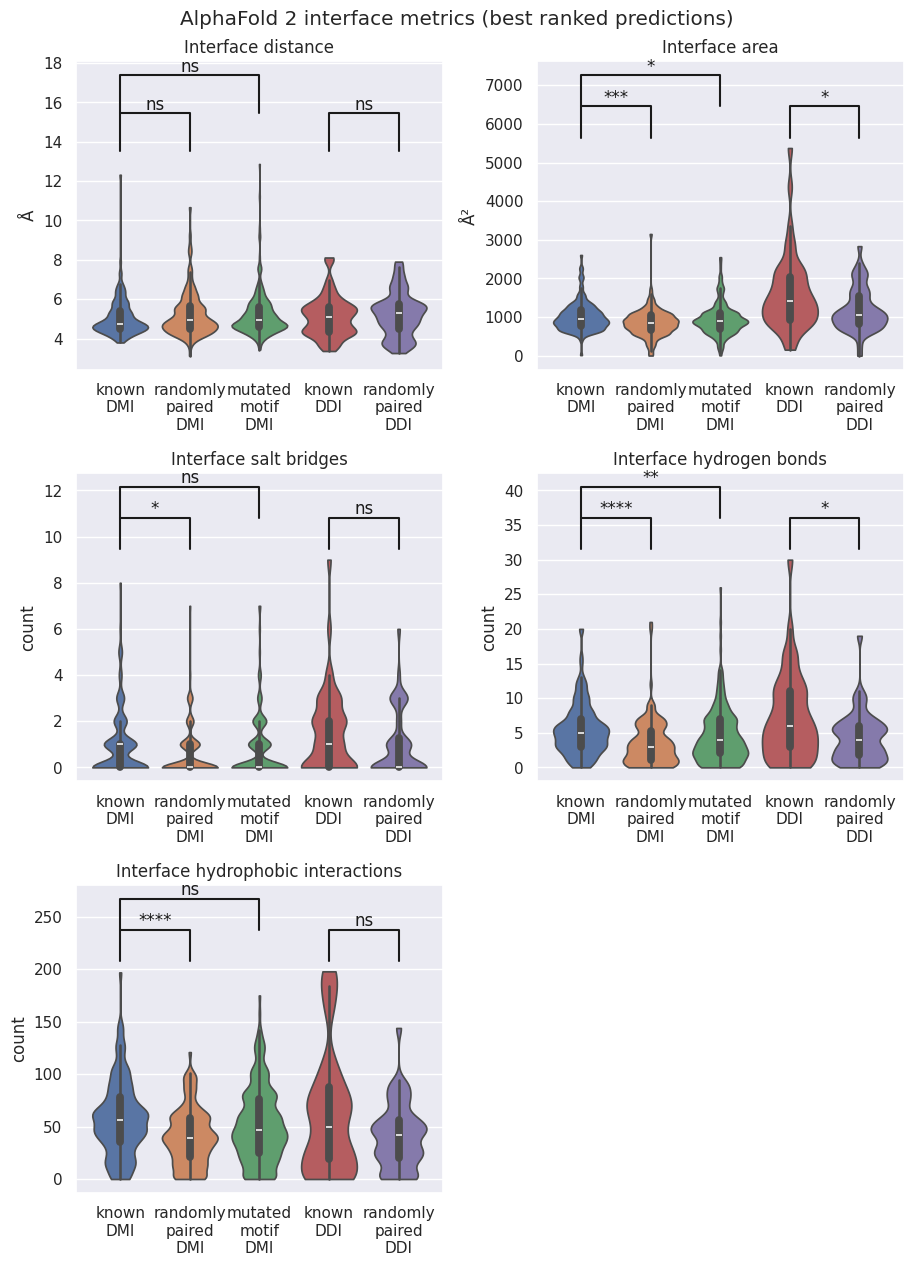

In [25]:
plot_violinplot(af_v="AF2", model_filter=True, rmsd_filter=False, save=True)

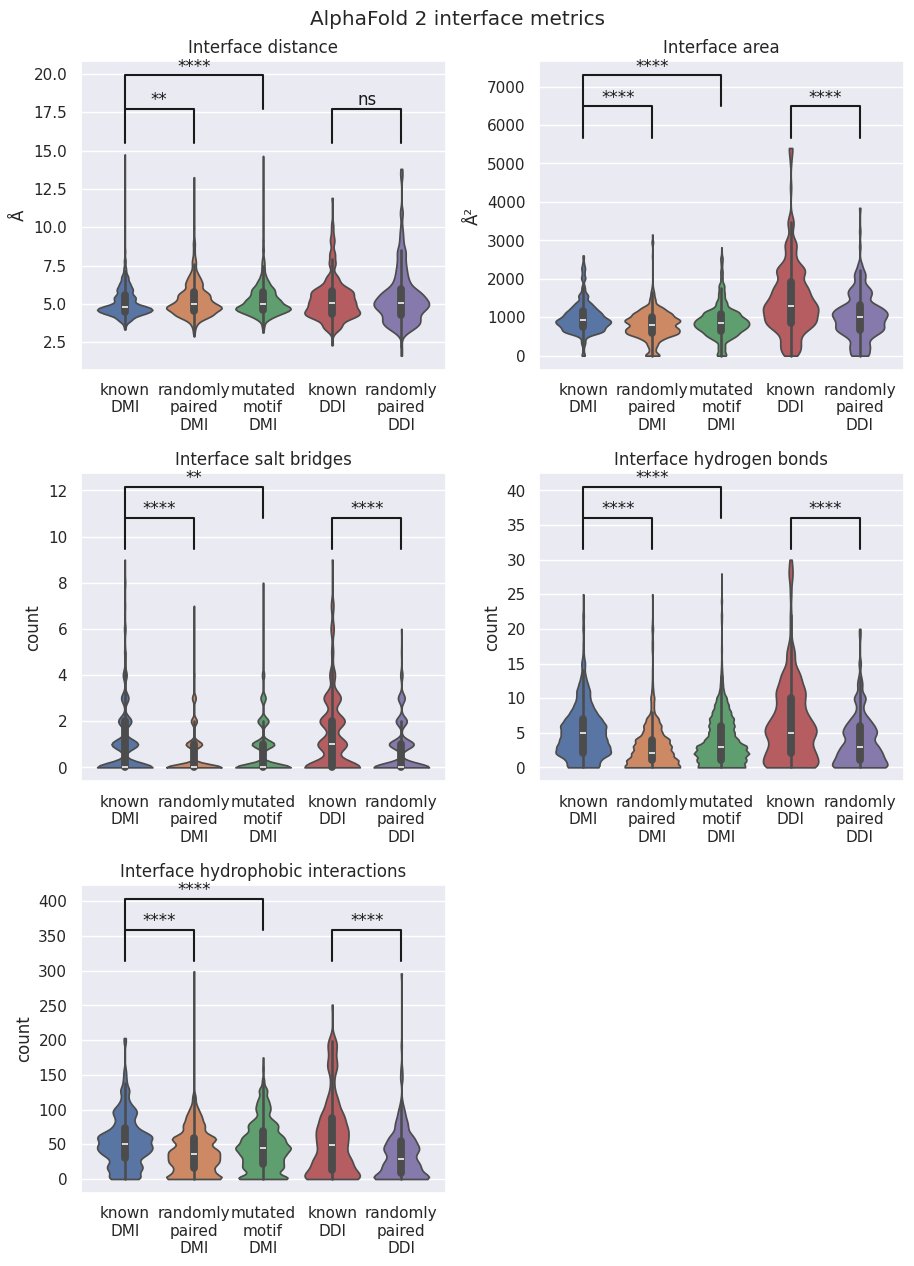

In [26]:
plot_violinplot(af_v="AF2", model_filter=False, rmsd_filter=False, save=True)

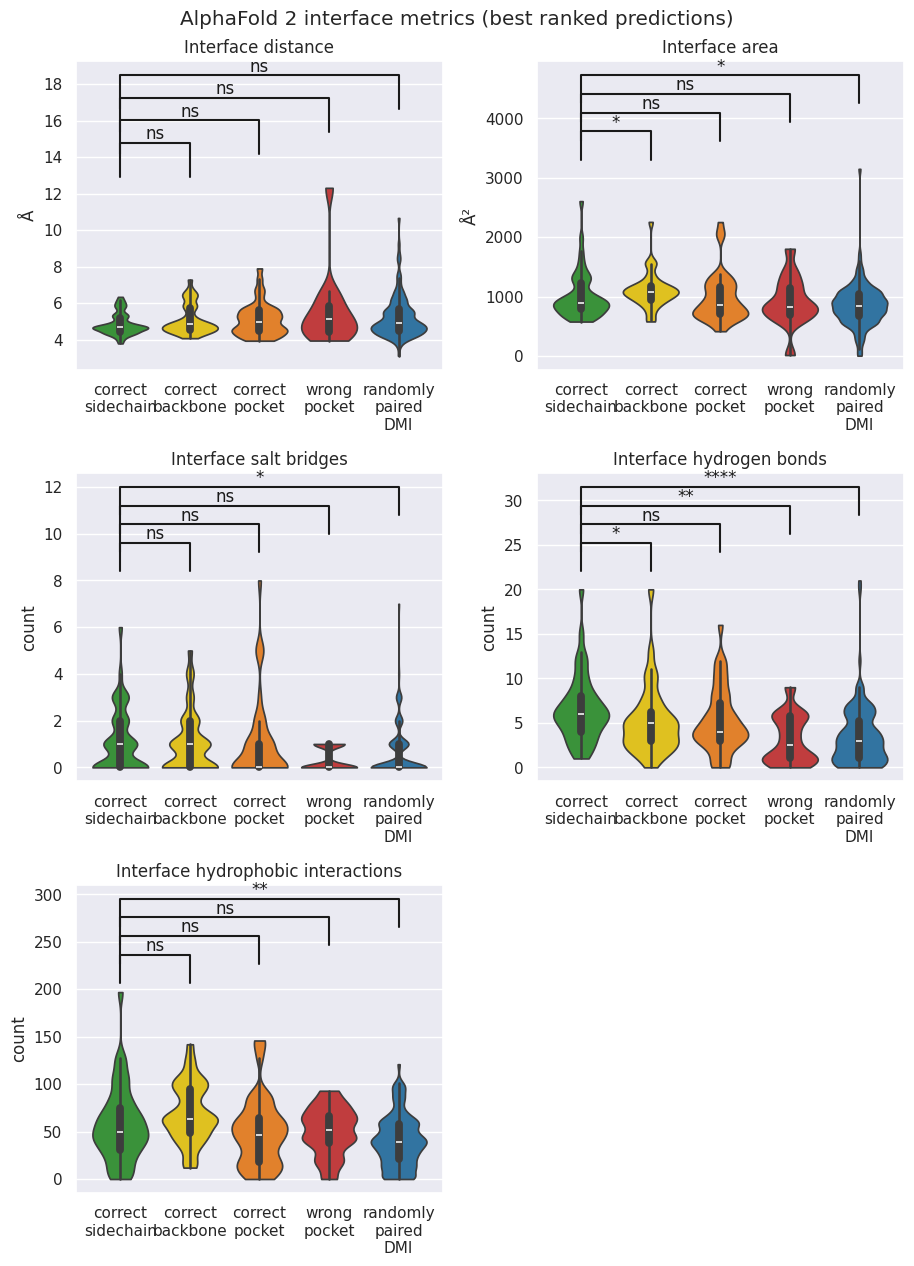

In [27]:
plot_violinplot(af_v="AF2", model_filter=True, rmsd_filter=True, save=True)

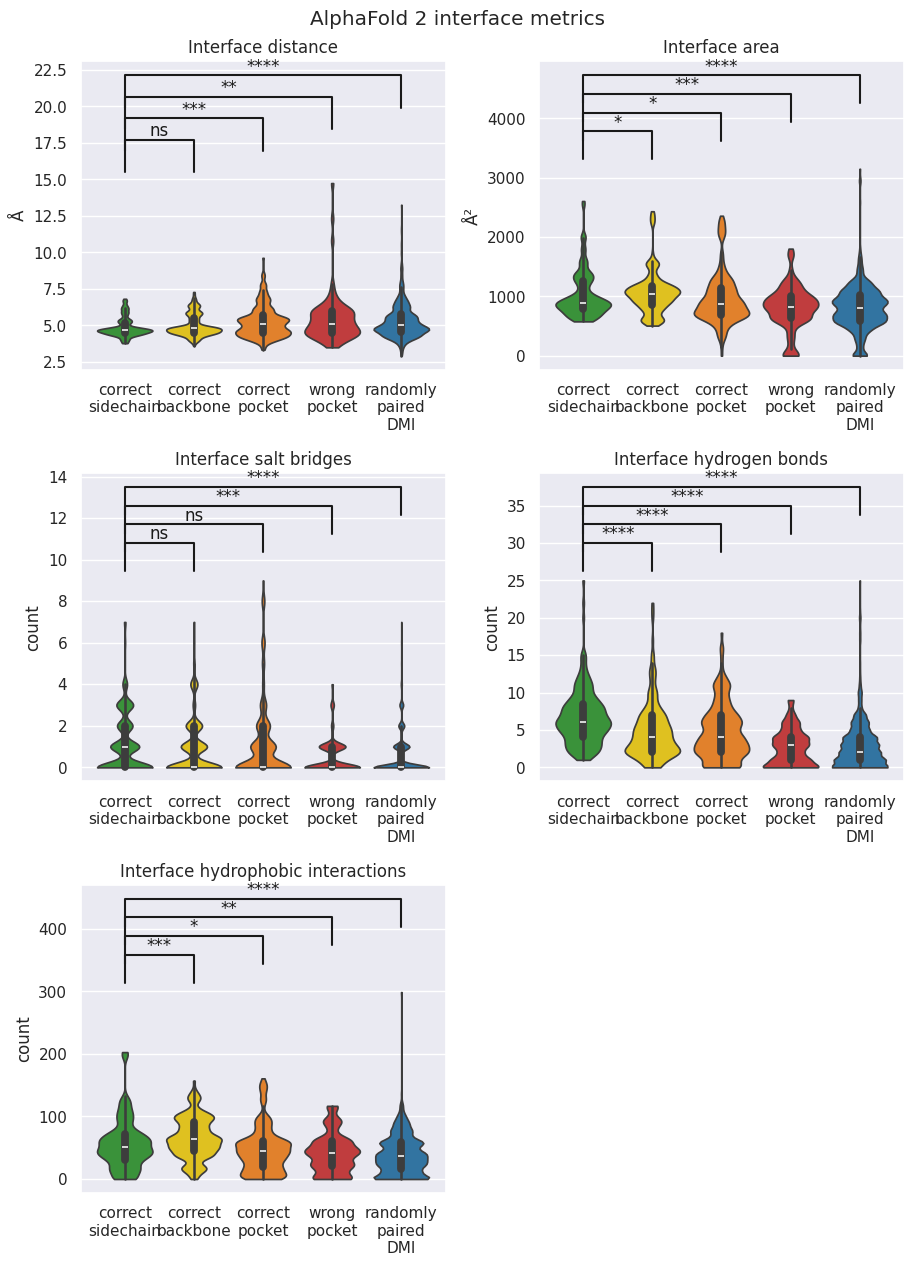

In [28]:
plot_violinplot(af_v="AF2", model_filter=False, rmsd_filter=True, save=True)

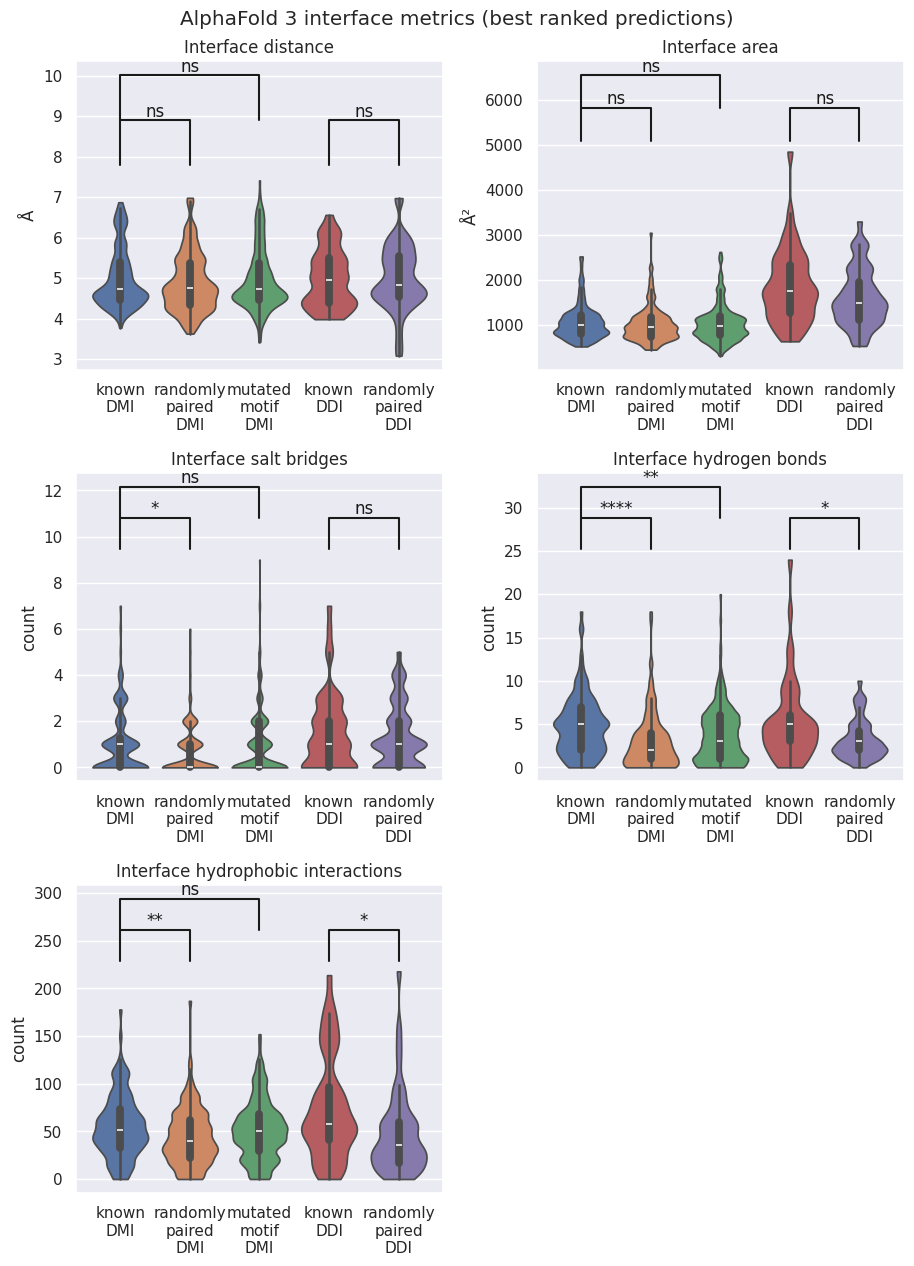

In [29]:
plot_violinplot(af_v="AF3", model_filter=True, rmsd_filter=False, save=True)

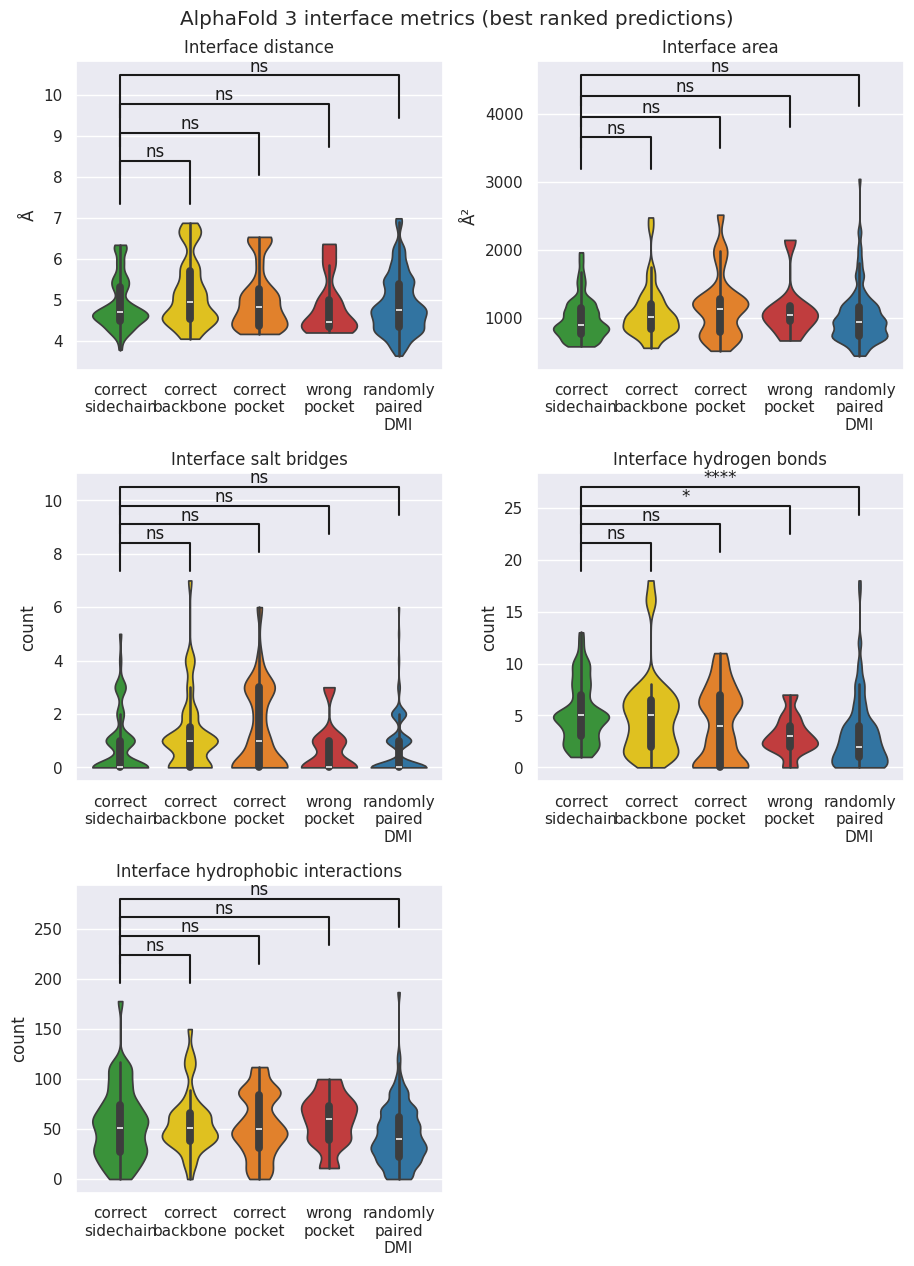

In [30]:
plot_violinplot(af_v="AF3", model_filter=True, rmsd_filter=True, save=True)

### Appendix

Quick check if I really work with the Lee et all dataset

In [ ]:
dataLee_knownDMI = pd.read_excel(path_resources / "benchmark set" / "Lee et al supplemental" / "44320_2023_5_moesm3_esm.xlsx", sheet_name="AF-MMv2.2 result")
_merge = pd.merge(
    left=dataLee_knownDMI,
    right=dataAF,
    how="inner",
    on=["prediction_name", "model_id"],
    suffixes=["_Lee", ""]
)
display(_merge[["prediction_name", "model_confidence", "model_confidence_AF2", "RMSD_all_atom_peptide", "RMSD_all_atom_peptide_AF2", "iPAE", "iPAE_AF2", "DockQ", "DockQ_AF2"]])

,prediction_name,model_confidence,model_confidence_AF2,RMSD_all_atom_peptide,RMSD_all_atom_peptide_AF2,iPAE,iPAE_AF2,DockQ,DockQ_AF2
0,DEG_SIAH_1_2A25,0.920907,0.920907,0.787199,0.787199,1.807006,1.807006,0.959,0.959489
1,DOC_USP7_MATH_1_3MQS,0.923664,0.923664,0.795526,0.795526,1.655897,1.655897,0.976,0.976485
2,DOC_PP2B_PxIxI_1_4F0Z,0.950851,0.950851,0.811035,0.811035,1.753244,1.753244,0.959,0.958922
3,DEG_Kelch_Keap1_1_2FLU,0.938596,0.938596,0.914587,0.914587,2.017997,2.017997,0.968,0.967567
4,LIG_TRAF2_2_1CZY,0.861203,0.861203,0.914688,0.914688,2.535973,2.535973,0.961,0.960978
...,...,...,...,...,...,...,...,...,...
131,LIG_FAT_LD_1_3GM1,0.885796,0.885796,27.508253,27.508253,1.883687,1.883687,0.035,0.035058
132,LIG_Clathr_ClatBox_2_1UTC,0.545352,0.545352,31.001265,31.001265,13.229383,13.229383,0.031,0.030790
133,DOC_PP1_MyPhoNE_1_1S70,0.611319,0.611319,39.227875,39.227875,8.118887,8.118887,0.019,0.018599
134,LIG_APCC_ABBA_1_4BH6,0.446541,0.446541,40.003876,40.003876,15.089235,15.089235,0.019,0.018725


In [ ]:
dataLee2_knownDMI = pd.read_csv(path_AF2 / "John metrics" / "AF_metrics_all_structures.tsv", sep="\t")
_merge = pd.merge(
    left=dataLee2_knownDMI,
    right=dataAF,
    how="inner",
    on=["prediction_name", "model_id"],
    suffixes=["_Lee", ""]
)
c = "RMSD_all_atom_peptide"
_merge[(np.abs(_merge[c] - _merge[f"{c}_AF2"]) > 0.002) & (_merge["benchmark_set"] == "known_DMI") & (_merge["model_id"] == "ranked_0")][["prediction_name", "model_id", "benchmark_set", c, f"{c}_AF2"]]

,prediction_name,model_id,benchmark_set,RMSD_all_atom_peptide,RMSD_all_atom_peptide_AF2
165,LIG_ActinCP_TwfCPI_2_7DS2,ranked_0,known_DMI,3.855830,3.923908
555,LIG_SUFU_1_4KMD,ranked_0,known_DMI,9.109661,10.008429


In [ ]:
_merge[_merge["PDB_id"] == "6VQG"][["prediction_name", "model_id", "benchmark_set", "DockQ", "DockQ_AF2"]]

,prediction_name,model_id,benchmark_set,DockQ,DockQ_AF2
2710,PF00137_PF07850_6VQG_i_resi7_resi86.p_resi292_...,ranked_0,known_DDI,0.341,0.292971
2711,PF00137_PF07850_6VQG_i_resi7_resi86.p_resi292_...,ranked_1,known_DDI,0.227,0.202566
2712,PF00137_PF07850_6VQG_i_resi7_resi86.p_resi292_...,ranked_2,known_DDI,0.058,0.054767
2713,PF00137_PF07850_6VQG_i_resi7_resi86.p_resi292_...,ranked_3,known_DDI,0.119,0.113379
2714,PF00137_PF07850_6VQG_i_resi7_resi86.p_resi292_...,ranked_4,known_DDI,0.139,0.129578
2850,D1PF00137_PF07850_6VQG.D2PF00244_PF01161_3AXY,ranked_0,random_DDI,NaN,NaN
2851,D1PF00137_PF07850_6VQG.D2PF00244_PF01161_3AXY,ranked_1,random_DDI,NaN,NaN
2852,D1PF00137_PF07850_6VQG.D2PF00244_PF01161_3AXY,ranked_2,random_DDI,NaN,NaN
2853,D1PF00137_PF07850_6VQG.D2PF00244_PF01161_3AXY,ranked_3,random_DDI,NaN,NaN
2854,D1PF00137_PF07850_6VQG.D2PF00244_PF01161_3AXY,ranked_4,random_DDI,NaN,NaN


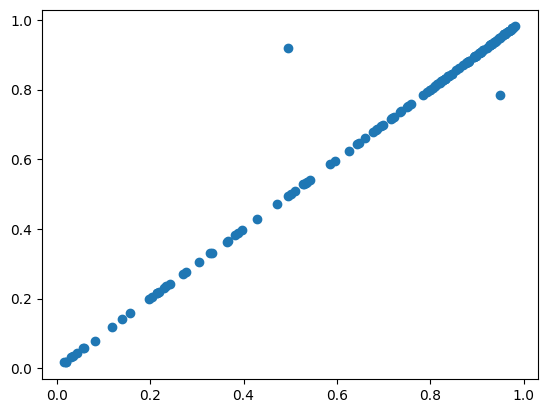

In [ ]:
plt.scatter(_merge["DockQ"], _merge["DockQ_AF2"])

Also, is the ranking working?

In [ ]:
dataAF[dataAF["score_rank"] != dataAF.groupby("prediction_name")["model_id"].rank("first").astype(pd.Int64Dtype())]

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,Fnonnat_AF2,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2


In [ ]:
b = "RMSD_rank"
display(dataAF[(dataAF[f"{b}_AF2"].isna() | dataAF[f"{b}_AF3"].isna())])
b = "RMSD_peptide_rank"
display(dataAF[(dataAF["benchmark_set"].str.contains("known") | dataAF["benchmark_set"].str.contains("mutations")) & (dataAF[f"{b}_AF2"].isna() | dataAF[f"{b}_AF3"].isna())])
b = "DockQ_rank"
display(dataAF[(dataAF["benchmark_set"].str.contains("known")) & (dataAF[f"{b}_AF2"].isna() | dataAF[f"{b}_AF3"].isna())])

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,score_rank_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2
1085,alphafold3,random_DMI,MLIG_MYND_2_2ODD.DMOD_SUMO_for_1_1KPS,ranked_0,0.28,159,41,A,B,0,...,556.732,4.886,0.0,0,1,1,1,<NA>,<NA>,<NA>
1086,alphafold3,random_DMI,MLIG_MYND_2_2ODD.DMOD_SUMO_for_1_1KPS,ranked_1,0.28,159,41,A,B,0,...,847.302,4.427,0.0,1,3,17,2,<NA>,<NA>,<NA>
1087,alphafold3,random_DMI,MLIG_MYND_2_2ODD.DMOD_SUMO_for_1_1KPS,ranked_2,0.27,159,41,A,B,0,...,651.759,4.757,0.0,1,1,8,3,<NA>,<NA>,<NA>
1088,alphafold3,random_DMI,MLIG_MYND_2_2ODD.DMOD_SUMO_for_1_1KPS,ranked_3,0.24,159,41,A,B,0,...,649.890,4.134,0.0,0,4,22,4,<NA>,<NA>,<NA>
1089,alphafold3,random_DMI,MLIG_MYND_2_2ODD.DMOD_SUMO_for_1_1KPS,ranked_4,0.22,159,41,A,B,0,...,767.292,4.281,0.0,1,1,45,5,<NA>,<NA>,<NA>
1115,alphafold3,random_DMI,MLIG_PAM2_1_1JGN.DMOD_CDK_SPxK_1_2CCI,ranked_0,0.54,297,13,A,B,<NA>,...,984.822,4.435,0.0,1,3,26,1,<NA>,<NA>,<NA>
1116,alphafold3,random_DMI,MLIG_PAM2_1_1JGN.DMOD_CDK_SPxK_1_2CCI,ranked_1,0.51,297,13,A,B,<NA>,...,959.145,3.480,0.0,0,4,69,2,<NA>,<NA>,<NA>
1117,alphafold3,random_DMI,MLIG_PAM2_1_1JGN.DMOD_CDK_SPxK_1_2CCI,ranked_2,0.49,297,13,A,B,<NA>,...,1168.572,3.492,0.0,0,10,124,3,<NA>,<NA>,<NA>
1118,alphafold3,random_DMI,MLIG_PAM2_1_1JGN.DMOD_CDK_SPxK_1_2CCI,ranked_3,0.45,297,13,A,B,<NA>,...,355.768,6.401,0.0,0,0,1,4,<NA>,<NA>,<NA>
1119,alphafold3,random_DMI,MLIG_PAM2_1_1JGN.DMOD_CDK_SPxK_1_2CCI,ranked_4,0.37,297,13,A,B,<NA>,...,275.464,5.736,0.0,0,0,0,5,<NA>,<NA>,<NA>


,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,score_rank_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2


,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,score_rank_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2
